# E-Commerce Analytics: Customer Segmentation, Market Basket Mining, and Sales Forecasting

Dataset -> https://archive.ics.uci.edu/dataset/352/online+retail

**Feature description:**
- `Invoice`: 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation
- `StockCode`: 5-digit integral number uniquely assigned to each distinct product
- `Description`: product name
- `Quantity`: the quantities of each product (item) per transaction
- `InvoiceDate`: the day and time when each transaction was generated
- `UnitPrice`: product price per unit (sterling)
- `Customer ID`: 5-digit integral number uniquely assigned to each customer
- `Country`: the name of the country where each customer resides

## Data Preparation & Cleaning

In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Data Exploration

In [203]:
# Load the data
path = '../data/online_retail_II.csv'
data = pd.read_csv(path)

In [204]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [205]:
data.rename(columns={
    'Invoice': 'InvoiceNo',
    'Price': 'UnitPrice',
    'Customer ID': 'CustomerID'
}, inplace=True)

In [206]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   UnitPrice    541910 non-null  float64
 6   CustomerID   406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


`Insight`: We have some missing CustomerID along with a few of the missing product description, and InvoiceDate is not in the correct format(datetime).

In [207]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [208]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


`Insight`: Quantity and UnitPrice have minimum values as negative, which might be the result due to the returns, and this data is not useful for further analysis.

In [209]:
data.describe(include='object')

,InvoiceNo,StockCode,Description,Country
count,541910,541910,540456,541910
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


In [210]:
data[data['CustomerID'].isna()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom


`Insight`: For the first transaction there's no product Description, UnitPrice, and CustomerID but Quantity is recorded which is unsusual behavior. Even for the legit transactions CustomerID is absent. This is impossible to categorize or effectively work on that data because it's near impossible to infer which customer made this purchase.

In [211]:
data[data['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


`Insight`: According to the data description the if this InvoiceNo starts with letter 'C', it indicates a cancellation.

In [212]:
data['InvoiceNo'] = data['InvoiceNo'].astype(str)

# Validate the Invoice number pattern
data[data['InvoiceNo'].str.match(r'^\d{6}$') == False]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


Check if the transactions with InvoiceNo starts with only C from the above result.

In [213]:
data['InvoiceNo'].str.replace(r'[0-9]', '', regex=True).unique()

array(['', 'C', 'A'], dtype=object)

We have transactions not only starts with 'C' but also starts with 'A'.

In [214]:
data[data['InvoiceNo'].str.startswith('A')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


`Insight`: Three transactions are found with InvoiceNo starting with 'A', which are bad debt and missing CustomerID might represent transactions related to accounting. This data will not be useful for further analysis.

In [215]:
# Check if the StockCode has 5 digits
data[data['StockCode'].str.match(r'^\d{5}$') == False]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France
...,...,...,...,...,...,...,...,...
541809,581579,85099C,JUMBO BAG BAROQUE BLACK WHITE,10,2011-12-09 12:19:00,1.79,17581.0,United Kingdom
541841,581580,84993A,75 GREEN PETIT FOUR CASES,2,2011-12-09 12:20:00,0.42,12748.0,United Kingdom
541847,581580,85049A,TRADITIONAL CHRISTMAS RIBBONS,1,2011-12-09 12:20:00,1.25,12748.0,United Kingdom
541856,581580,85049E,SCANDINAVIAN REDS RIBBONS,2,2011-12-09 12:20:00,1.25,12748.0,United Kingdom


`Insight`: We got lot of transactions with StockCode that do not follow the pattern and StockCode(s) that follow the pattern include letters at the end. Although, these transactions look legit and nothing mentioned about these letters in the data documentation. So, assuming these are valid.

In [216]:
data[(data['StockCode'].str.match(r'^\d{5}$') == False) & (data['StockCode'].str.match(r'^\d{5}[a-zA-Z]+$') == False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.00,12791.0,Netherlands
1123,536527,POST,POSTAGE,1,2010-12-01 13:04:00,18.00,12662.0,Germany
1423,536540,C2,CARRIAGE,1,2010-12-01 14:05:00,50.00,14911.0,EIRE
...,...,...,...,...,...,...,...,...
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541730,581570,POST,POSTAGE,1,2011-12-09 11:59:00,18.00,12662.0,Germany
541767,581574,POST,POSTAGE,2,2011-12-09 12:09:00,18.00,12526.0,Germany
541768,581578,POST,POSTAGE,3,2011-12-09 12:16:00,18.00,12713.0,Germany


`Insight`: There are 2996 transactions with the StockCode that do not follow the pattern according to the data description and some of them have null customers.

In [217]:
data[(data['StockCode'].str.match(r'^\d{5}$') == False) & (data['StockCode'].str.match(r'^\d{5}[a-zA-Z]+$') == False)]['StockCode'].unique()

array(['POST', 'D', 'C2', 'DOT', 'M', 'BANK CHARGES', 'S', 'AMAZONFEE',
       'DCGS0076', 'DCGS0003', 'gift_0001_40', 'DCGS0070', 'm',
       'gift_0001_50', 'gift_0001_30', 'gift_0001_20', 'DCGS0055',
       'DCGS0072', 'DCGS0074', 'DCGS0069', 'DCGS0057', 'DCGSSBOY',
       'DCGSSGIRL', 'gift_0001_10', 'PADS', 'DCGS0004', 'DCGS0073',
       'DCGS0071', 'DCGS0066P', 'DCGS0068', 'DCGS0067', 'B', 'CRUK'],
      dtype=object)

`Insight`: These are the unique StockCode(s) that do not follow the pattern according to the data description. But some of them might be legit, so let's investigate each of these StockCode(s) see if we need them for further analysis.

In [218]:
# Get the unique StockCodes
unique_stockcodes = data[(data['StockCode'].str.match(r'^\d{5}$') == False) & 
                         (data['StockCode'].str.match(r'^\d{5}[a-zA-Z]+$') == False)]['StockCode'].unique()

# Get the description for each unique StockCode
stockcode_descriptions = data[data['StockCode'].isin(unique_stockcodes)][['StockCode', 'Description']].drop_duplicates()
stockcode_descriptions

,StockCode,Description
45,POST,POSTAGE
141,D,Discount
1423,C2,CARRIAGE
1815,DOT,DOTCOM POSTAGE
2239,M,Manual
4406,BANK CHARGES,Bank Charges
14436,S,SAMPLES
14514,AMAZONFEE,AMAZON FEE
21326,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT
24906,DCGS0003,BOXED GLASS ASHTRAY


`Insight`: **StockCode**
- StockCode must be a *5-digit integral* number but seems to have *letters* also.
- All of these are non-product transactions and some of them have no description.
- Keeping the transactions with the codes below would create meaningless patterns in Market Basket Analysis and add noise to the sales forecasting.
    | Code | Description |
    | ---- | ---- |
    | `POST`, `DOT` | Postage charges |
    | `D` | Discount applied to a transaction |
    | `C2` | Carriage/shipping fees |
    | `M` or `m` | Manual entry, often used for administrative adjustments |
    | `BANK CHARGES` | Fees from bank transactions |
    | `AMAZONFEE` | Fees related to Amazon sales |
    | `CRUK` | Not sure |
    | `B` | Bad debt adjustments |
    | `S` | Sample items |
- `PADS` seems to be legit, could be included
- `gift_0001_XX`: Could be included for sales forecasting 

### Data Cleaning

In [219]:
cleaned_data = data.copy()

In [220]:
# Remove transactions containing cancellations and accounting
mask_invoice = (cleaned_data['InvoiceNo'].str.match(r'^\d{6}$') == True)

cleaned_data = cleaned_data[mask_invoice]
cleaned_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [221]:
cleaned_data[cleaned_data['InvoiceNo'].str.startswith('C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [222]:
cleaned_data[cleaned_data['InvoiceNo'].str.startswith('A')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


Now we have no transactions with cancelled products and accounting related.

In [223]:
# Remove Non-Product StockCodes
# Remove administrative codes we identified earlier
admin_codes = ['POST', 'DOT', 'D', 'C2', 'M', 'm', 'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'B', 'S']

mask_stockcode = (
    (~cleaned_data['StockCode'].isin(admin_codes)) &
    (
        (cleaned_data['StockCode'].str.match(r'^\d{5}$')) |
        (cleaned_data['StockCode'] == 'PADS')
    )
)

cleaned_data = cleaned_data[mask_stockcode]
cleaned_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [224]:
cleaned_data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,478989.000000,478989,478989.000000,363123.000000
mean,10.495577,2011-07-07 07:24:16.750029568,3.260386,15295.740325
min,-9600.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,1.000000,2011-03-30 16:34:00,1.250000,13969.000000
50%,4.000000,2011-07-24 13:13:00,2.080000,15159.000000
75%,12.000000,2011-10-20 15:57:00,4.130000,16794.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,167.222977,NaN,4.440983,1711.940134


Still the Quantity have negative values, UnitPrice have minimum value as `0`, and null customers need to be removed.

In [225]:
cleaned_data.dropna(subset=['CustomerID'], inplace=True)

In [226]:
cleaned_data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,363123.000000,363123,363123.000000,363123.000000
mean,13.128929,2011-07-12 18:02:28.604521984,2.886066,15295.740325
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-10 11:33:00,1.250000,13969.000000
50%,6.000000,2011-08-03 10:49:00,1.700000,15159.000000
75%,12.000000,2011-10-21 14:49:00,3.750000,16794.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,188.526817,NaN,4.361958,1711.940134


In [227]:
print(f"Transactions with 0 price: {len(cleaned_data[cleaned_data['UnitPrice'] == 0])}")

Transactions with 0 price: 33


In [228]:
cleaned_data = cleaned_data[cleaned_data['UnitPrice'] > 0]

In [229]:
cleaned_data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,363090.000000,363090,363090.000000,363090.000000
mean,13.091944,2011-07-12 18:01:57.053623296,2.886328,15295.839065
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-10 11:33:00,1.250000,13969.000000
50%,6.000000,2011-08-03 10:49:00,1.740000,15159.000000
75%,12.000000,2011-10-21 14:47:15,3.750000,16794.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,187.384433,NaN,4.362069,1711.921687


In [230]:
print(f"Dropped about {(len(data) - len(cleaned_data))/len(data):.2%} of the data during cleaning.")

Dropped about 33.00% of the data during cleaning.


In [231]:
cleaned_data.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [232]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 363090 entries, 1 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    363090 non-null  object        
 1   StockCode    363090 non-null  object        
 2   Description  363090 non-null  object        
 3   Quantity     363090 non-null  int64         
 4   InvoiceDate  363090 non-null  datetime64[ns]
 5   UnitPrice    363090 non-null  float64       
 6   CustomerID   363090 non-null  float64       
 7   Country      363090 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 24.9+ MB


## 1. RFM Analysis & Customer Segmentation (Clustering)
Who are our customers?
- Convert the transaction log into a customer-level summary.

In [235]:
# Create a new column 'TotalPrice'
cleaned_data['TotalPrice'] = cleaned_data['Quantity'] * cleaned_data['UnitPrice']

In [236]:
cleaned_data[['Quantity', 'UnitPrice', 'TotalPrice']].head(10)

,Quantity,UnitPrice,TotalPrice
1,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,6,4.25,25.50
10,3,4.95,14.85
11,3,4.95,14.85
12,3,4.95,14.85
13,32,1.69,54.08


In [237]:
snapshot_date = cleaned_data['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Last Invoice date:", snapshot_date)

Last Invoice date: 2011-12-10 12:50:00


### RFM analysis
- Recency (R): Days since the last purchase.
- Frequency (F): Count of unique invoices (How frequent they are purchasing).
- Monetary (M): Sum of TotalPrice (How much they have spent).

In [238]:
# Group by CustomerID to calculate Recency, Frequency, and Monetary
customer_rfm = cleaned_data.groupby('CustomerID', as_index=False).agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'MonetaryValue'
})

customer_rfm.head(10)

,CustomerID,Recency,Frequency,MonetaryValue
0,12346.0,326,1,77183.60
1,12347.0,2,7,3653.45
2,12348.0,75,4,1437.24
3,12349.0,19,1,1372.42
4,12350.0,310,1,258.00
5,12352.0,36,7,1373.24
6,12353.0,204,1,89.00
7,12354.0,232,1,1062.80
8,12355.0,214,1,363.10
9,12356.0,23,3,2406.63


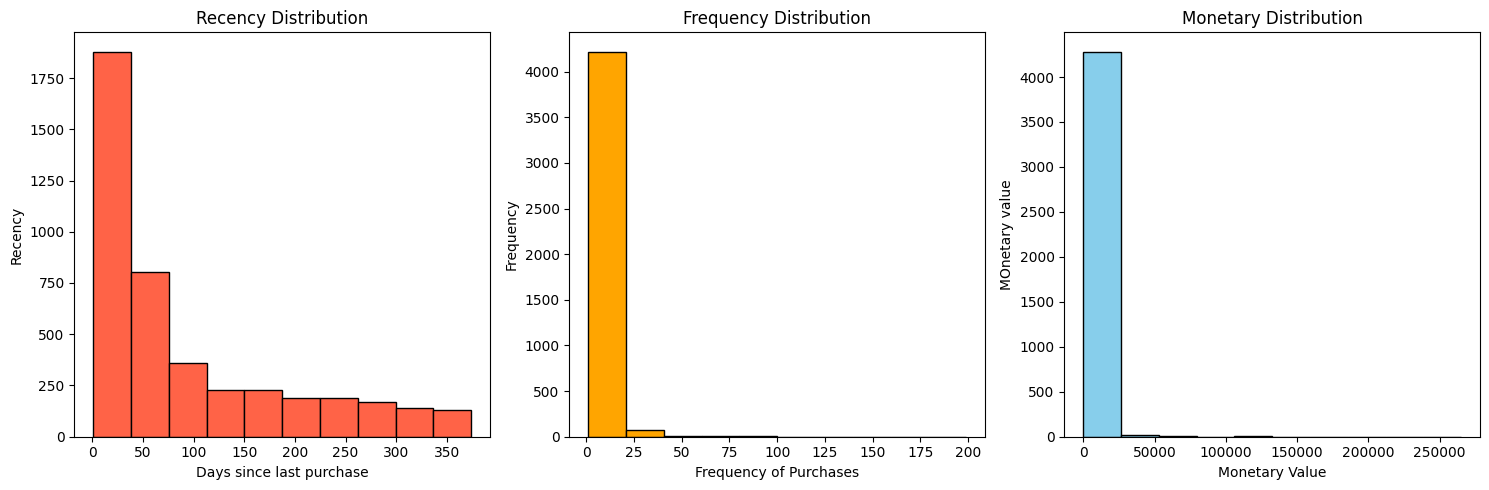

In [239]:
# Check the distribution of RFM values
# %pip install matplotlib

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(customer_rfm['Recency'], bins=10, color='tomato', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Days since last purchase')
plt.ylabel('Recency')

plt.subplot(1, 3, 2)
plt.hist(customer_rfm['Frequency'], bins=10, color='orange', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(customer_rfm['MonetaryValue'], bins=10, color='skyblue', edgecolor='black')
plt.title('Monetary Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('MOnetary value')

plt.tight_layout()
plt.show()

- Recency seems to have a resonable distribution.
- Frequency and Monetary have most of the distribution is towards 0.

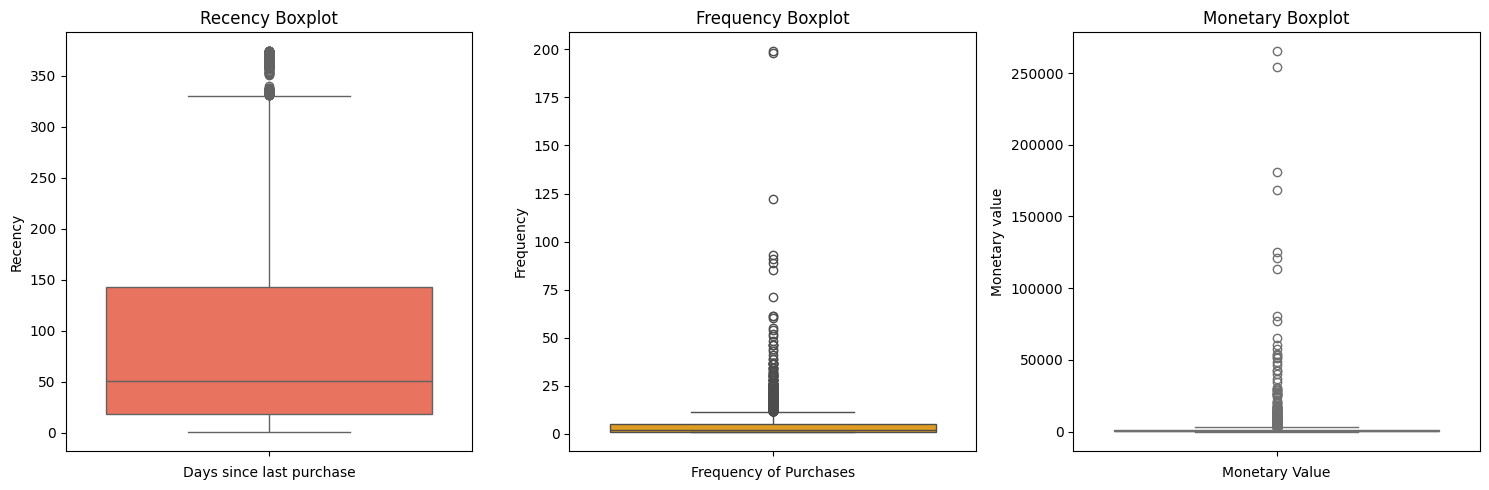

In [240]:
# Check for the outliers
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(customer_rfm['Recency'], color='tomato')
plt.title('Recency Boxplot')
plt.xlabel('Days since last purchase')
plt.ylabel('Recency')

plt.subplot(1, 3, 2)
sns.boxplot(customer_rfm['Frequency'], color='orange')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(customer_rfm['MonetaryValue'], color='skyblue')
plt.title('Monetary Boxplot')
plt.xlabel('Monetary Value')
plt.ylabel('Monetary value')

plt.tight_layout()
plt.show()

- Recency have few outliers.
- Whereas, Frequency and Monetary have huge number of outliers

We can remove them but there will be data loss, these data points are also important to understand the customers in the analysis.

In [241]:
Monetary_Q1 = customer_rfm['MonetaryValue'].quantile(0.25)
Monetary_Q3 = customer_rfm['MonetaryValue'].quantile(0.75)
Monetary_IQR = Monetary_Q3 - Monetary_Q1
Monetary_outliers = customer_rfm[(customer_rfm['MonetaryValue'] > (Monetary_Q3+1.5*Monetary_IQR)) | (customer_rfm['MonetaryValue'] < (Monetary_Q1-1.5*Monetary_IQR))]
Monetary_outliers.describe()

,CustomerID,Recency,Frequency,MonetaryValue
count,415.000000,415.000000,415.000000,415.000000
mean,15058.756627,23.744578,16.638554,11713.042602
std,1805.395901,44.180595,18.901332,25034.610798
min,12346.000000,1.000000,1.000000,3346.000000
25%,13360.500000,3.500000,8.000000,4048.235000
50%,15032.000000,10.000000,12.000000,5392.650000
75%,16678.000000,24.000000,19.000000,8720.120000
max,18251.000000,372.000000,199.000000,265106.920000


In [242]:
Freq_Q1 = customer_rfm['Frequency'].quantile(0.25)
Freq_Q3 = customer_rfm['Frequency'].quantile(0.75)
Freq_IQR = Freq_Q3 - Freq_Q1
Freq_outliers = customer_rfm[(customer_rfm['Frequency'] > (Freq_Q3+1.5*Freq_IQR)) | (customer_rfm['Frequency'] < (Freq_Q1-1.5*Freq_IQR))]
Freq_outliers.describe()

,CustomerID,Recency,Frequency,MonetaryValue
count,274.000000,274.000000,274.000000,274.000000
mean,15361.540146,13.945255,23.007299,13392.313759
std,1754.293469,30.608013,20.852876,28642.587282
min,12395.000000,1.000000,12.000000,1128.440000
25%,13880.250000,3.000000,13.000000,3939.572500
50%,15290.500000,6.000000,17.000000,5933.695000
75%,16806.000000,15.750000,25.000000,10522.685000
max,18283.000000,372.000000,199.000000,265106.920000


`Insight`: Some of the `MonetaryValue` outliers might be `Frequency` outliers. Which means someone buying frequently are probably spending more.

In [243]:
customer_rfm_filtered = customer_rfm[
    (~customer_rfm['MonetaryValue'].isin(Monetary_outliers['MonetaryValue'])) &
    (~customer_rfm['Frequency'].isin(Freq_outliers['Frequency']))
]

customer_rfm_filtered.describe()

,CustomerID,Recency,Frequency,MonetaryValue
count,3848.000000,3848.000000,3848.000000,3848.00000
mean,15315.410603,101.265852,2.745842,787.06556
std,1707.587165,102.082100,2.157524,739.26597
min,12348.000000,1.000000,1.000000,4.25000
25%,13844.750000,22.750000,1.000000,243.44500
50%,15321.500000,59.000000,2.000000,521.22500
75%,16785.000000,162.000000,4.000000,1104.28000
max,18287.000000,374.000000,11.000000,3327.53000


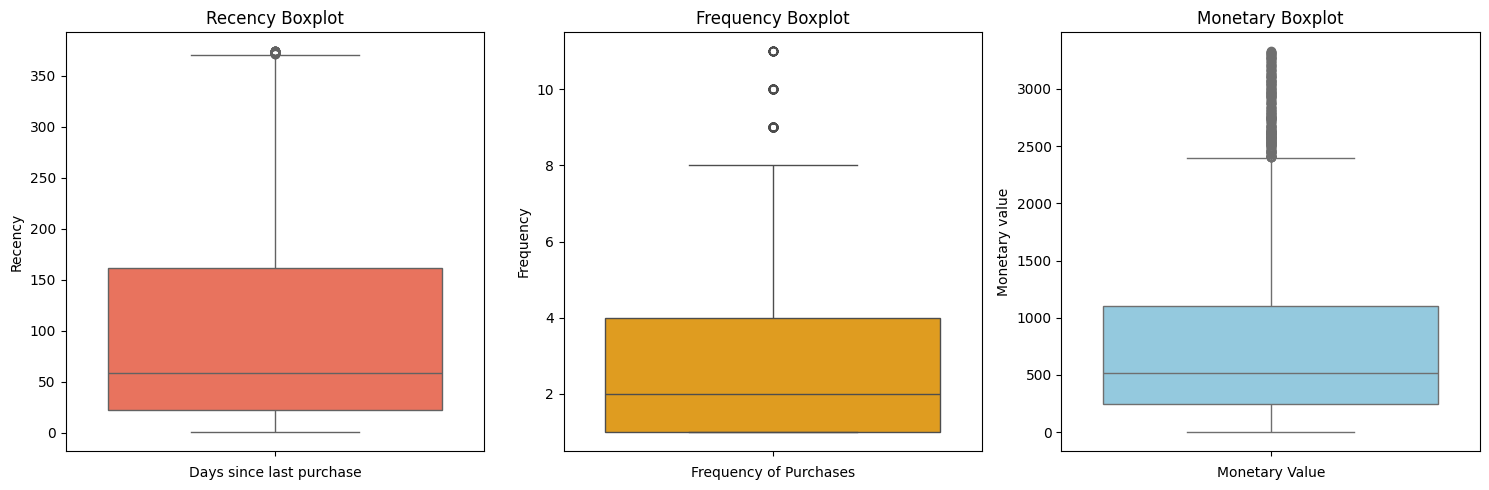

In [244]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(customer_rfm_filtered['Recency'], color='tomato')
plt.title('Recency Boxplot')
plt.xlabel('Days since last purchase')
plt.ylabel('Recency')

plt.subplot(1, 3, 2)
sns.boxplot(customer_rfm_filtered['Frequency'], color='orange')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(customer_rfm_filtered['MonetaryValue'], color='skyblue')
plt.title('Monetary Boxplot')
plt.xlabel('Monetary Value')
plt.ylabel('Monetary value')

plt.tight_layout()
plt.show()

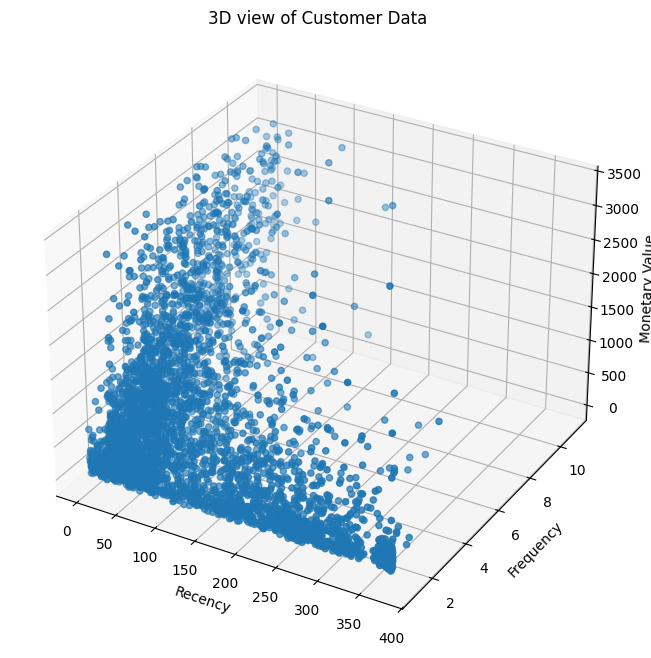

In [245]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    customer_rfm_filtered['Recency'],
    customer_rfm_filtered['Frequency'],
    customer_rfm_filtered['MonetaryValue']
)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary Value')

ax.set_title('3D view of Customer Data')
plt.show()

### Customer Segmentation (Clustering)

As these three features have difference scales clustering using `KMeans` algorithms is sensotive to different scale data. Hence, these need to be standardized.

In [246]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_scaled = scaler.fit_transform(customer_rfm_filtered[['Recency', 'Frequency', 'MonetaryValue']])
data_scaled

array([[-0.25733469,  0.58137066,  0.8796008 ],
       [-0.80598405, -0.80929302,  0.79190784],
       [ 2.04503312, -0.80929302, -0.71575636],
       ...,
       [ 0.78118015, -0.80929302, -0.95545768],
       [-0.91375445, -0.34573846, -0.82391823],
       [-0.57084861,  0.1178161 ,  0.58578473]], shape=(3848, 3))

In [247]:
data_scaled_df = pd.DataFrame(data_scaled, 
                              columns=['Recency', 'Frequency', 'MonetaryValue'], 
                              index=customer_rfm_filtered.index)
data_scaled_df

,Recency,Frequency,MonetaryValue
2,-0.257335,0.581371,0.879601
3,-0.805984,-0.809293,0.791908
4,2.045033,-0.809293,-0.715756
5,-0.639430,1.972034,0.793017
6,1.006518,-0.809293,-0.944391
...,...,...,...
4308,-0.267132,-0.809293,-0.829533
4309,1.731519,-0.809293,-0.820468
4310,0.781180,-0.809293,-0.955458
4311,-0.913754,-0.345738,-0.823918


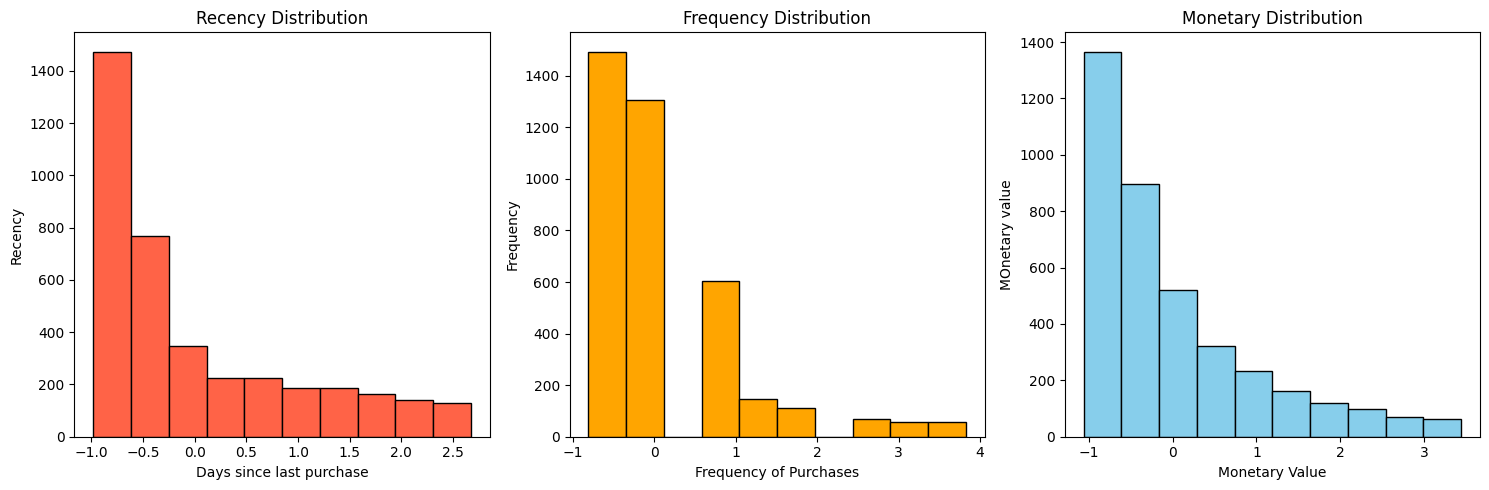

In [256]:
# Check the distribution of RFM values
# %pip install matplotlib

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(data_scaled_df['Recency'], bins=10, color='tomato', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Days since last purchase')
plt.ylabel('Recency')

plt.subplot(1, 3, 2)
plt.hist(data_scaled_df['Frequency'], bins=10, color='orange', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(data_scaled_df['MonetaryValue'], bins=10, color='skyblue', edgecolor='black')
plt.title('Monetary Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('MOnetary value')

plt.tight_layout()
plt.show()

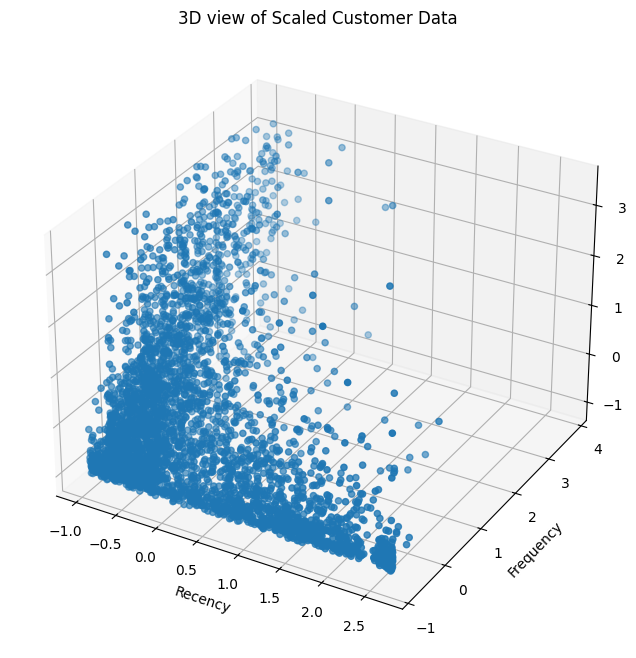

In [248]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    data_scaled_df['Recency'],
    data_scaled_df['Frequency'],
    data_scaled_df['MonetaryValue']
)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary Value')

ax.set_title('3D view of Scaled Customer Data')
plt.show()

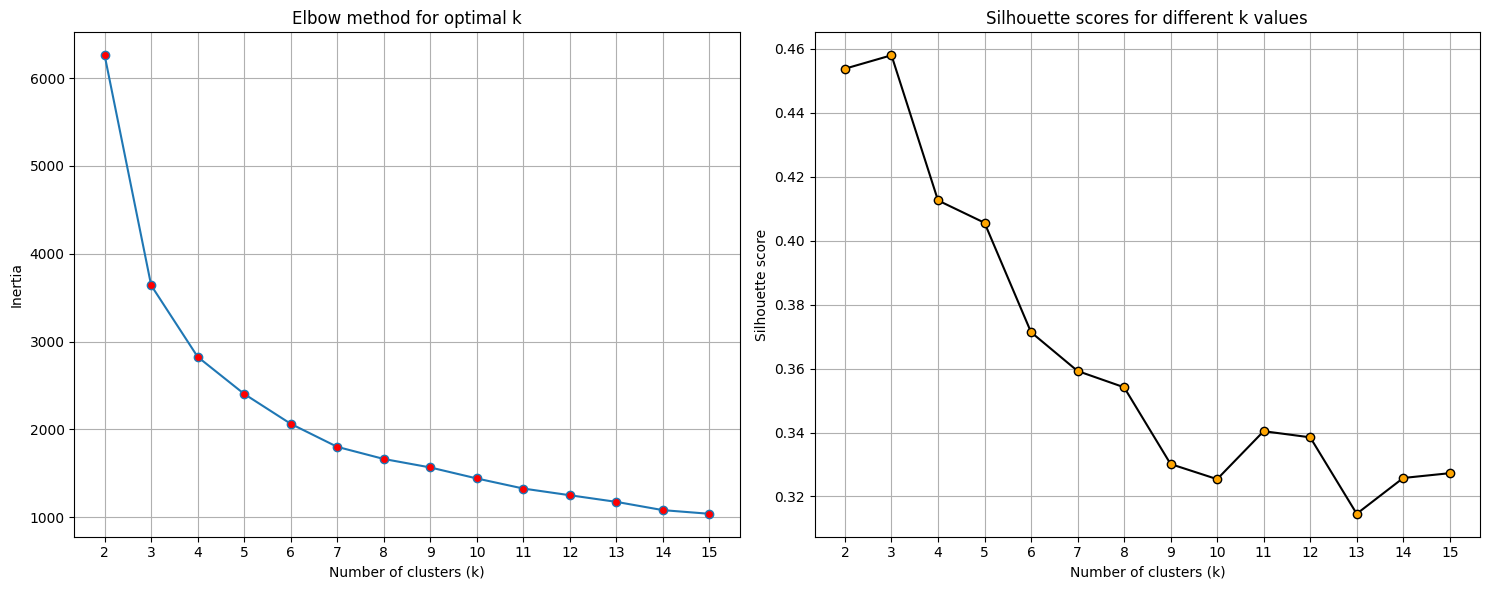

In [250]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

MAX_CLUSTERS = 15
inertia_values = []
silhouette_scores = []
k_values = range(2, MAX_CLUSTERS + 1)

for k in k_values:
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=1,
        max_iter=1000
    )
    clusters = kmeans_model.fit_predict(data_scaled_df)

    sil_score = silhouette_score(data_scaled_df, clusters)

    inertia = kmeans_model.inertia_
    inertia_values.append(inertia)
    silhouette_scores.append(sil_score)

# Plot the inertia values for different k values
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia_values, marker='o', markerfacecolor='red')
plt.title('Elbow method for optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, color='black', marker='o', markerfacecolor='orange')
plt.title('Silhouette scores for different k values')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.xticks(k_values)
plt.grid()

plt.tight_layout()
plt.show()

`k` values 4 and 5 seems to be better choice. A metrics called `Silhouette score` will help use decide the number of clusters precisely.
- Silhouette score ranges between [-1, 1]
- Higher the score (near to 1) more distinct clusters
- Right plot shows that k=4 has the highest score than k=5

In [251]:
kmeans = KMeans(
    n_clusters = 4,
    random_state = 1,
    max_iter = 1000
)

cluster_labels = kmeans.fit_predict(data_scaled_df)
cluster_labels

array([1, 2, 0, ..., 0, 2, 1], shape=(3848,), dtype=int32)

In [252]:
customer_rfm_filtered['Cluster'] = cluster_labels
customer_rfm_filtered

,CustomerID,Recency,Frequency,MonetaryValue,Cluster
2,12348.0,75,4,1437.24,1
3,12349.0,19,1,1372.42,2
4,12350.0,310,1,258.00,0
5,12352.0,36,7,1373.24,3
6,12353.0,204,1,89.00,0
...,...,...,...,...,...
4308,18278.0,74,1,173.90,2
4309,18280.0,278,1,180.60,0
4310,18281.0,181,1,80.82,0
4311,18282.0,8,2,178.05,2


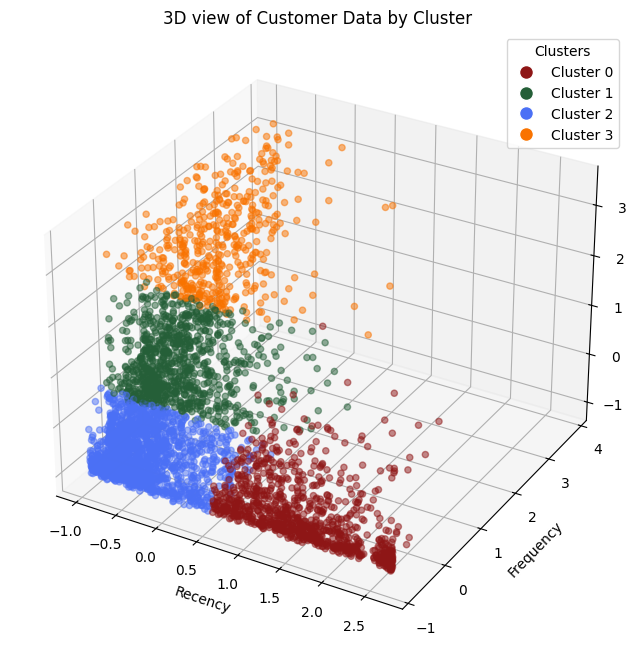

In [ ]:
# Visualize the clusters in 3D
cluster_colors = {
    0: '#8E1616',
    1: '#255F38',
    2: '#4B70F5',
    3: '#F97300'
}

colors = customer_rfm_filtered['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    data_scaled_df['Recency'],
    data_scaled_df['Frequency'],
    data_scaled_df['MonetaryValue'],
    c=colors,
    alpha=0.5,
    marker='o'
)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary Value')

ax.set_title('3D view of Customer Data by Cluster')
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {i}',
                               markerfacecolor=color, markersize=10) for i, color in cluster_colors.items()],
           title='Clusters', loc='upper right')
plt.show()

In [254]:
segment_summary = customer_rfm_filtered.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': 'mean'
}).round(2)

print(segment_summary)

         Recency  Frequency  MonetaryValue
Cluster                                   
0         259.64       1.36         343.84
1          48.29       3.93        1153.36
2          56.86       1.61         390.58
3          32.63       6.94        2260.98


K-Means algorithm has successfully separated customers into four distinct groups based on their RFM scores.
- Cluster 3 (Orange): `Champions` customers
    - This group has **very low Recency** (avg. 32 days), **very high Frequency** (avg. 7 purchases), and **high MonetaryValue** (avg. £2,261)
    - This group is the most valuable group.
- Cluster 2 (Blue): `New/Potential` customers
    - This group has **low Recency** (avg. 56 days), but very **low Frequency** (avg. 1.6 purchases) and **low Monetary value** (avg. £390).
    - They could be new customers or occasional shoppers who are promissing. They need to be actively engaged.
- Cluster 1 (Green): `Loyal Customers` customers
    - This group has **low Recency** (avg. 48 days), **good Frequency** (avg. 4 purchases), and **strong Monetary value** (avg. £1,153).
    - These customers are the backbone of the business. They are reliable and have high potential to become Champions.
- Cluster 0 (Dark Red): `At-Risk` customers
    - This group has **extremely high Recency** (avg. 260 days), and the **lowest Frequency** and **lowest Monetary values**.
    - These customers have likely churned. It's been almost 9 months since their last purchase.

## 2. Market Basket Analysis

Understanding which products are purchased together can inform merchandising strategies – for example, cross‑selling complementary items, arranging store or site layout so that frequently co‑purchased goods are close to each other, or designing bundle promotions. These types of insights are the goal of *market basket analysis*.

We will look for patterns of co‑occurrence in transactional data, which is also known as **frequent itemset mining**.

The strength of the relationships is measured using three key metrics:
1. `Support`: the proportion of transactions that contain a particular item or itemset. High support indicates that an itemset is frequent in the dataset.
2. `Confidence`: the conditional probability that a transaction containing the antecedent (left side) also contains the consequent (right side). High confidence suggests that purchasing the antecedent implies a high likelihood of purchasing the consequent.
3. `Lift`: measures how much more often the antecedent and consequent occur together compared with what would be expected if they were independent. It is the ratio of the confidence to the support of the consequent. A lift greater than 1 indicates a positive association; values below 1 mean the items occur together less than expected.

In [50]:
# Build the basket matrix (rows are invoices, columns are items)
basket = (cleaned_data
    .groupby(['InvoiceNo', 'Description'])['Quantity']
    .sum()
    .unstack()
    .fillna(0)
)

basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)

In [51]:
# Generate frequent itemsets and association rules
from mlxtend.frequent_patterns import apriori, association_rules

def apriori_analysis(basket_data, min_support= 0.01, min_threshold = 1, max_items=3):
    frequent_itemsets = apriori(basket_data, min_support=min_support, use_colnames=True, max_len=max_items)

    rules = association_rules(frequent_itemsets, metric='lift', min_threshold=min_threshold)
    rules = rules[rules['confidence'] >= 0.5]
    rules = rules.sort_values(by='lift', ascending=False)
    
    return frequent_itemsets, rules

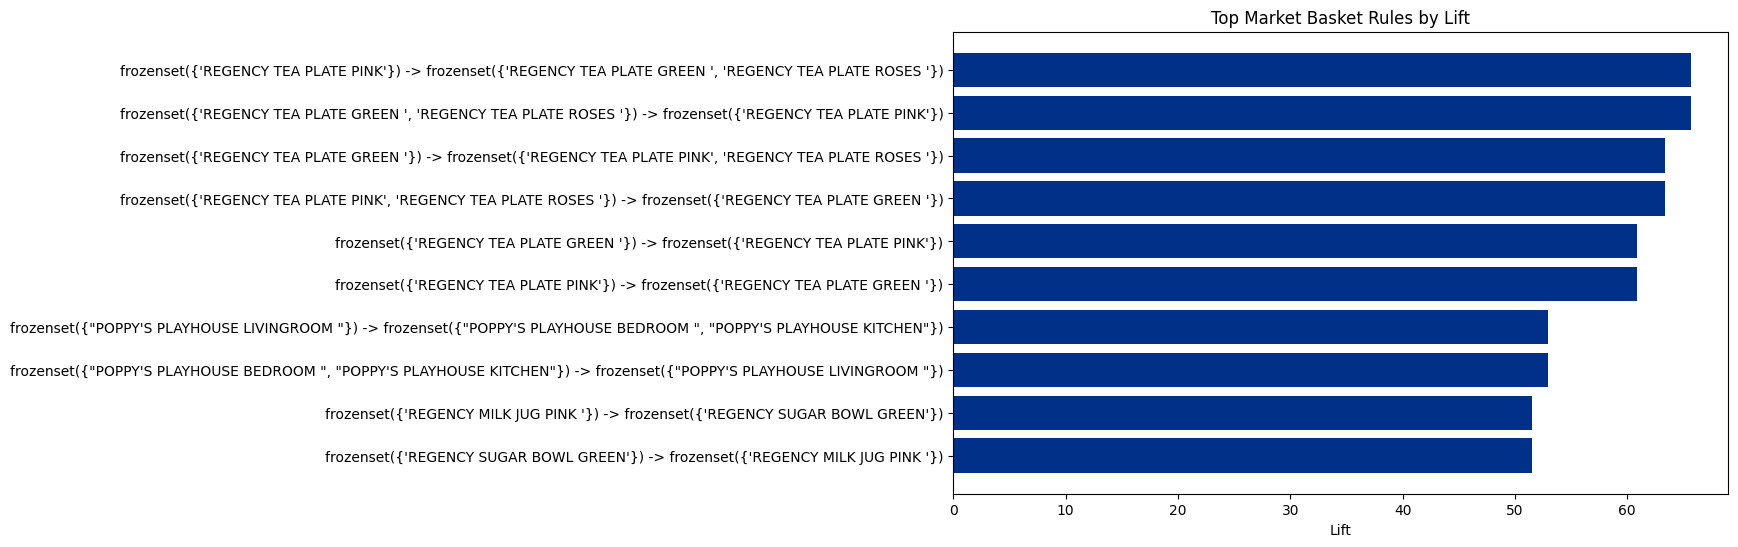

In [ ]:
# Run the apriori analysis
frequent_itemsets, rules = apriori_analysis(
    basket_sets,
    min_support=0.01,
    min_threshold=1,
    max_items=3
)

# Select top 10 rules by lift
top_rules = rules.head(10)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_rules)), top_rules['lift'], color='#003087')
plt.yticks(range(len(top_rules)), [f"{row['antecedents']} -> {row['consequents']}" 
                                   for _, row in top_rules.iterrows()])
plt.xlabel('Lift')
plt.title('Top Market Basket Rules by Lift')
plt.gca().invert_yaxis()
plt.show()

`Insights`:
1. The highest‑lift rules involve different colour variants of the same “`Regency Tea Plate`”.
    * When customers buy both the `Regency Tea Plate Green` and `Regency Tea Plate Roses` together, they almost always add the `Regency Tea Plate Pink` to their basket. 
    * The lift values around 60 mean this combination occurs about sixty times more often than you would expect if people picked these items independently.
    * In other words, shoppers treat the three colour variations as part of a matching set.
    * The pattern repeats when you look at two‑item antecedents: people who buy the `Regency Tea Plate Green` almost always also buy the `Regency Tea Plate Pink`, and vice versa.
    * This suggests very strong relation within the Regency Tea Plate range and highlights an opportunity to bundle or promote these variants together.
2. Another cluster appears around Poppy’s Playhouse toy sets.
    * Transactions containing both the `Poppy's Playhouse Kitchen` and the `Poppy's Playhouse Bedroom` almost always include the `Poppy's Playhouse Livingroom`.
    * Similarly, purchasing either the kitchen or bedroom sets greatly increases the likelihood of buying the living room set.
    * These rules suggest a logical progression: once parents start buying individual playhouse rooms, they tend to complete the collection.
3. The last pair of rules ties the `Regency sugar bowl` and `milk jug` together.
    * Customers who buy the `pink milk jug` frequently add the `green sugar bowl`, and the reverse is also true.
    * Lift values above 50 indicate a very strong association - again, people seem to favour matching items from the same product line.

Generating rules with minimum support: 0.01 and max itemsets: 2


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 851
Number of rules generated: 122
Time taken: 17.90 seconds


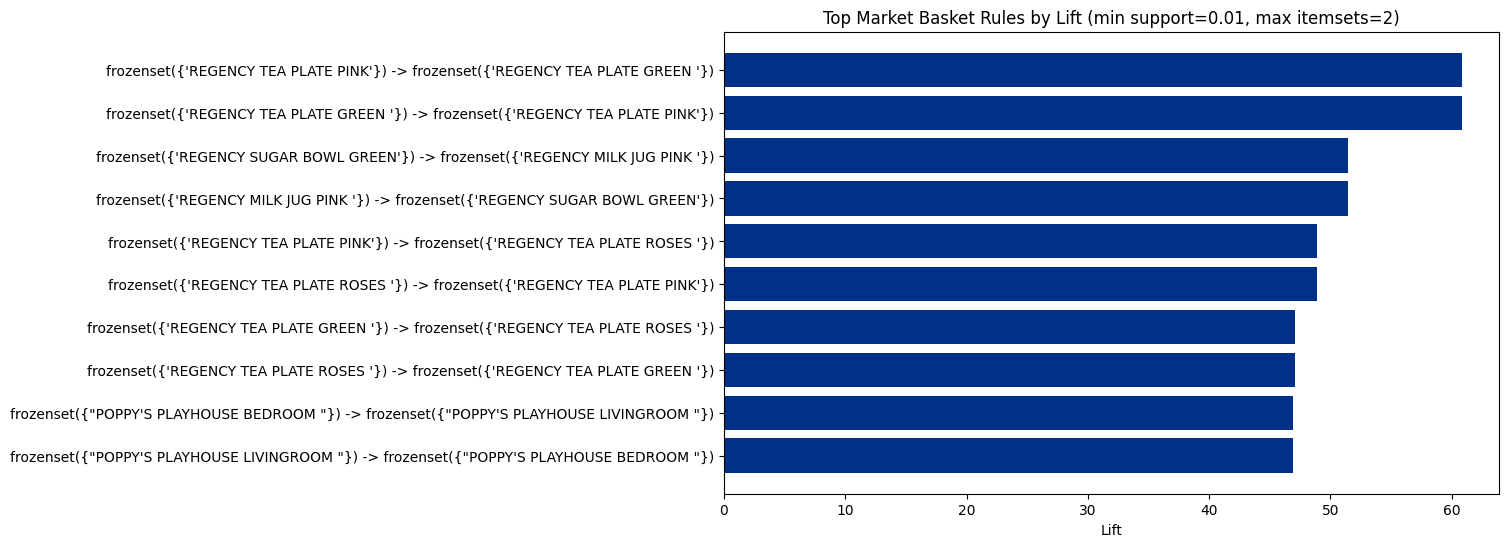

Generating rules with minimum support: 0.01 and max itemsets: 3


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 901
Number of rules generated: 251
Time taken: 18.91 seconds


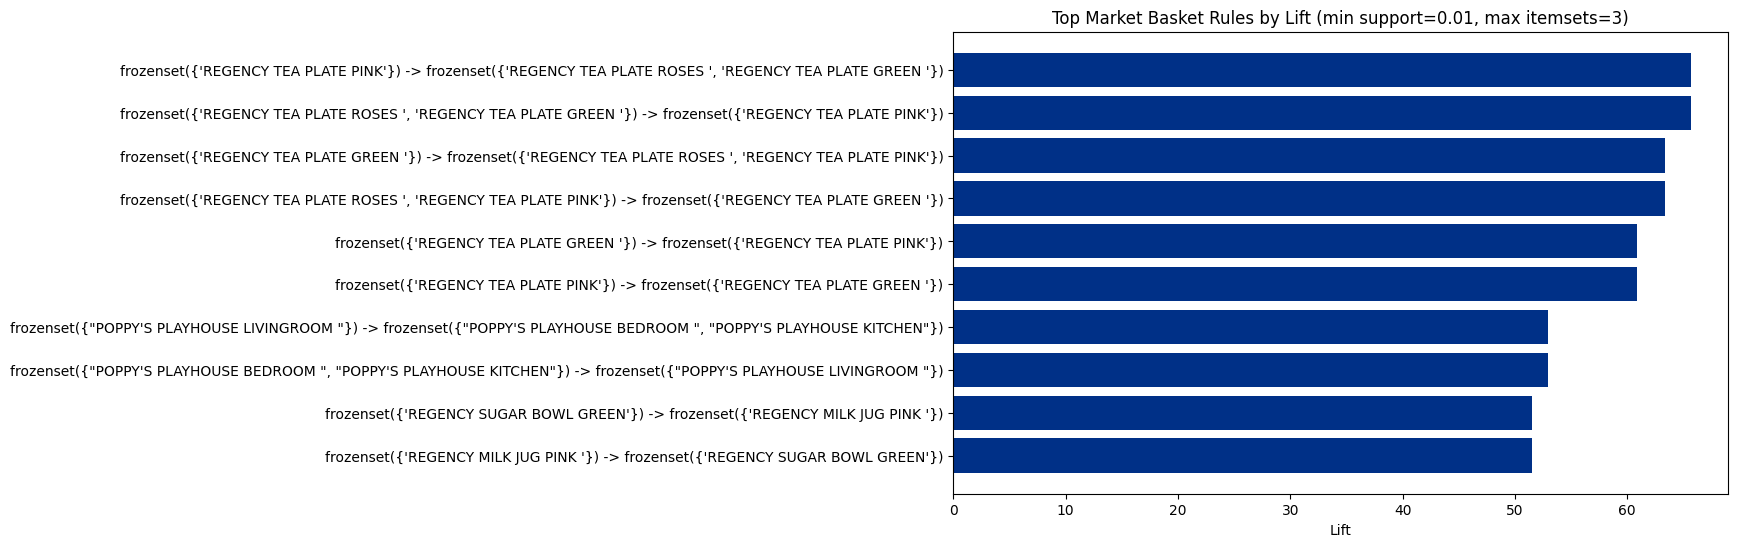

Generating rules with minimum support: 0.01 and max itemsets: 4


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 903
Number of rules generated: 264
Time taken: 18.55 seconds


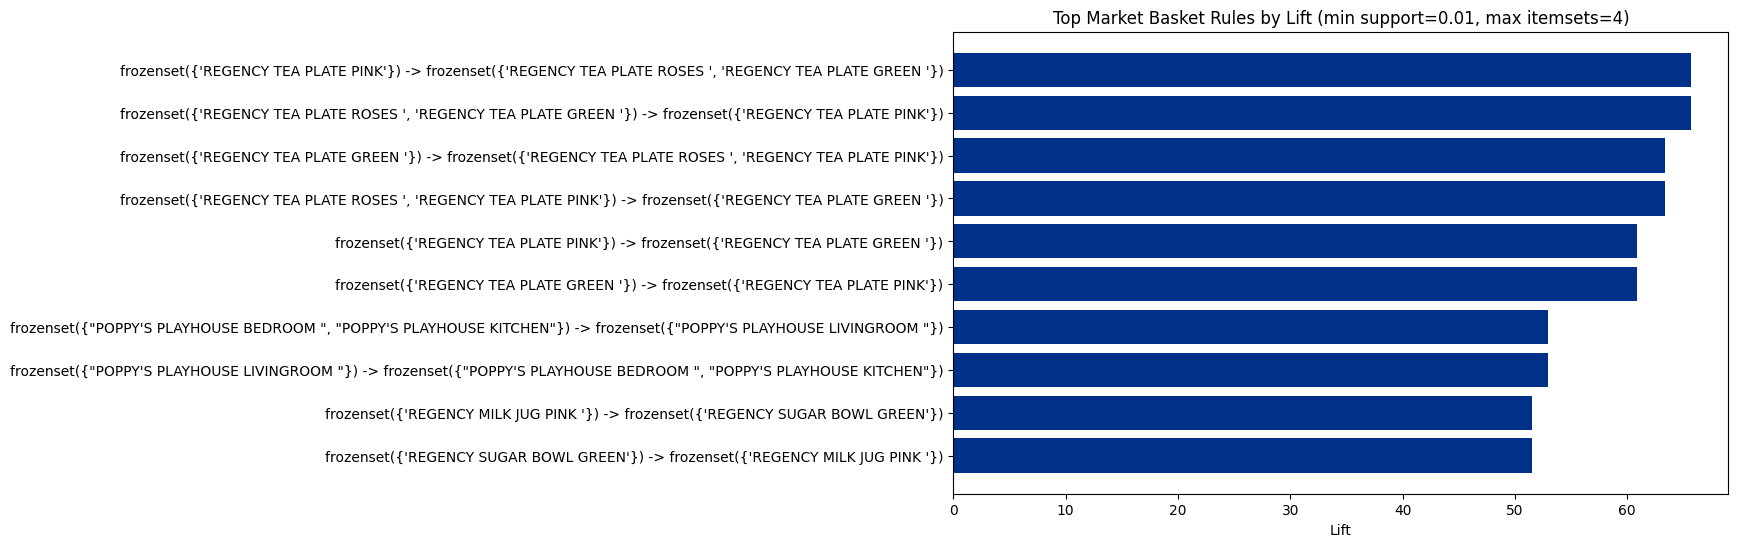

Generating rules with minimum support: 0.02 and max itemsets: 2


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 232
Number of rules generated: 20
Time taken: 1.22 seconds


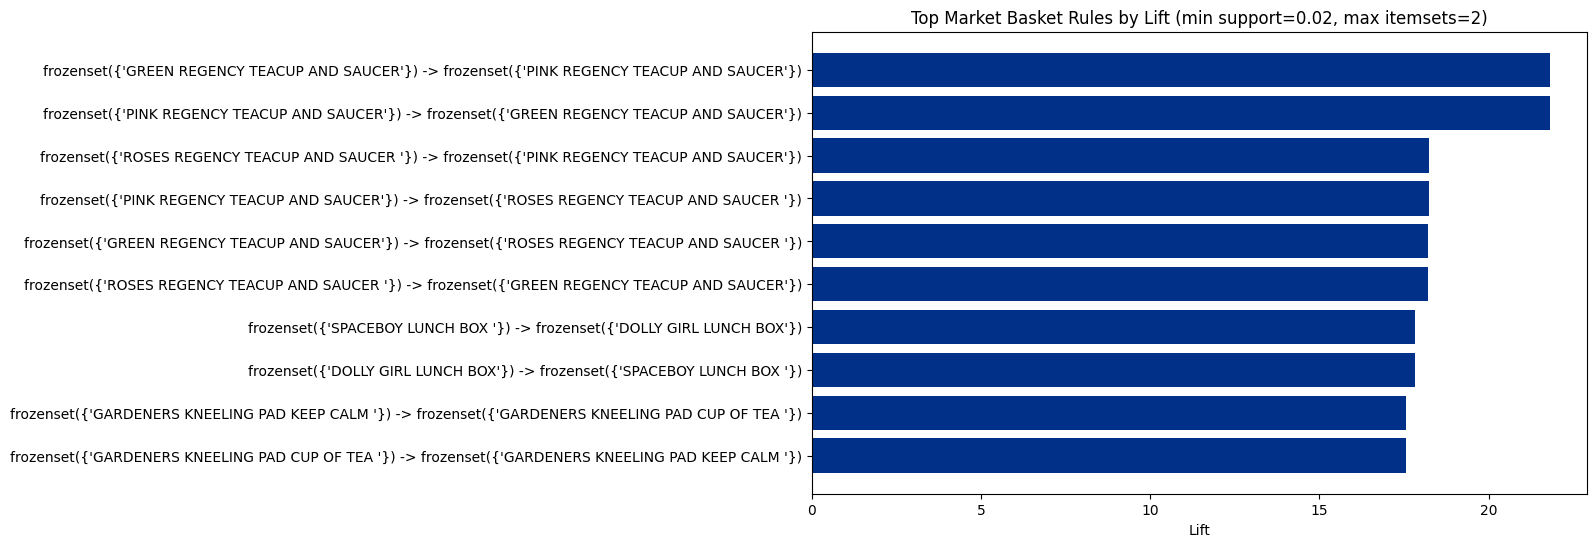

Generating rules with minimum support: 0.02 and max itemsets: 3


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 233
Number of rules generated: 25
Time taken: 1.22 seconds


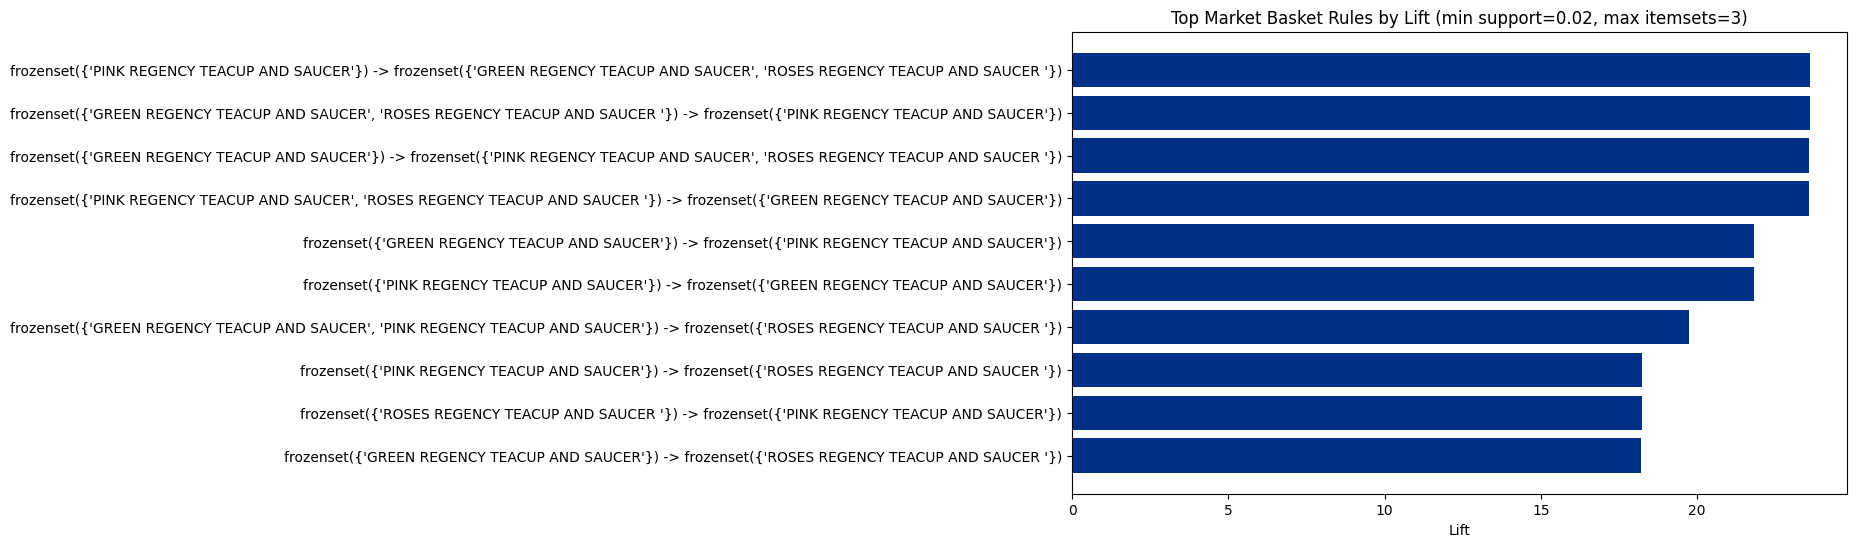

Generating rules with minimum support: 0.02 and max itemsets: 4


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 233
Number of rules generated: 25
Time taken: 1.16 seconds


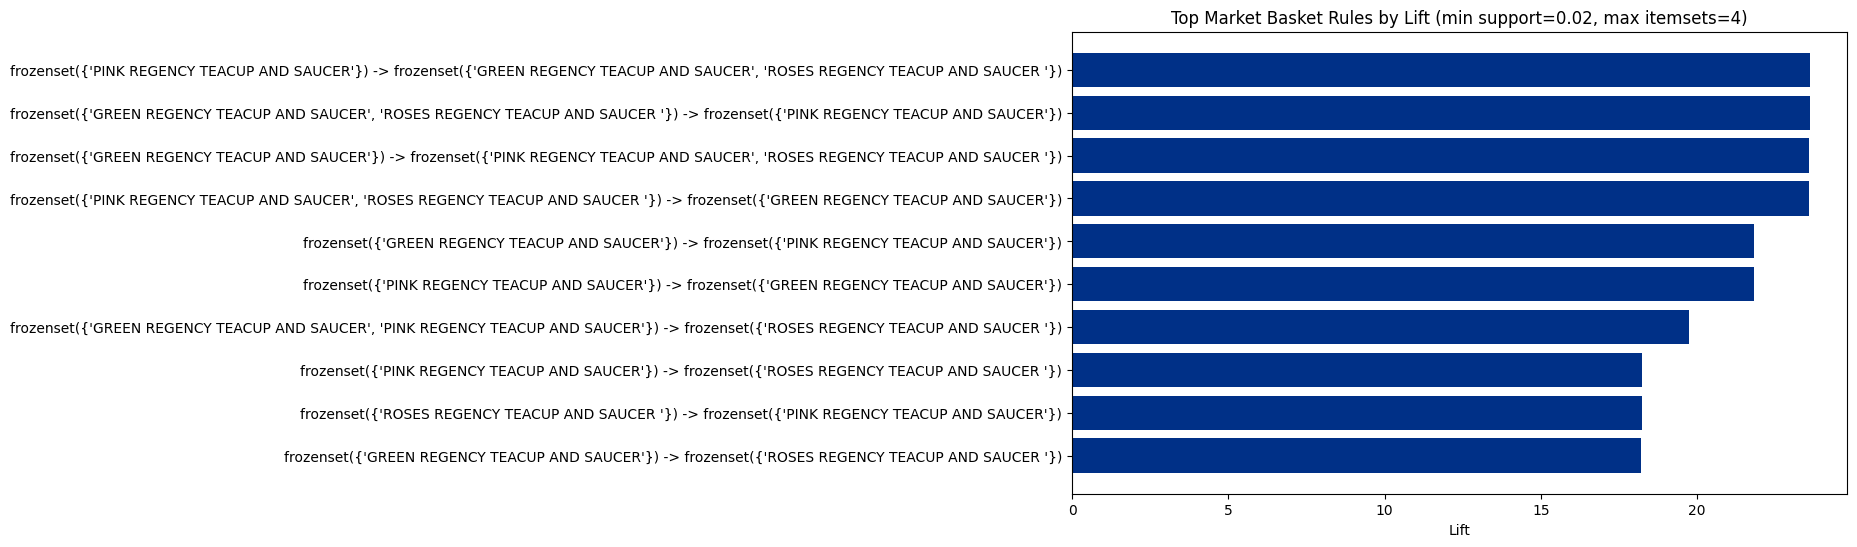

Generating rules with minimum support: 0.03 and max itemsets: 2


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 87
Number of rules generated: 0
Time taken: 0.28 seconds


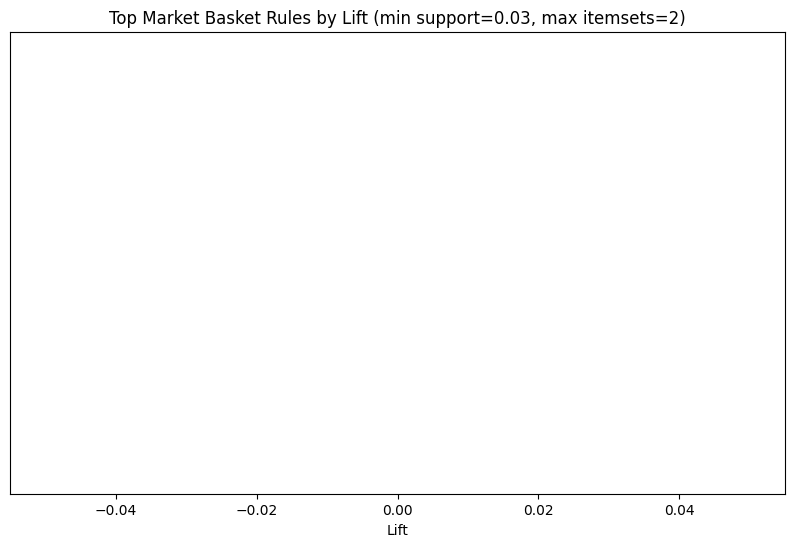

Generating rules with minimum support: 0.03 and max itemsets: 3


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 87
Number of rules generated: 0
Time taken: 0.28 seconds


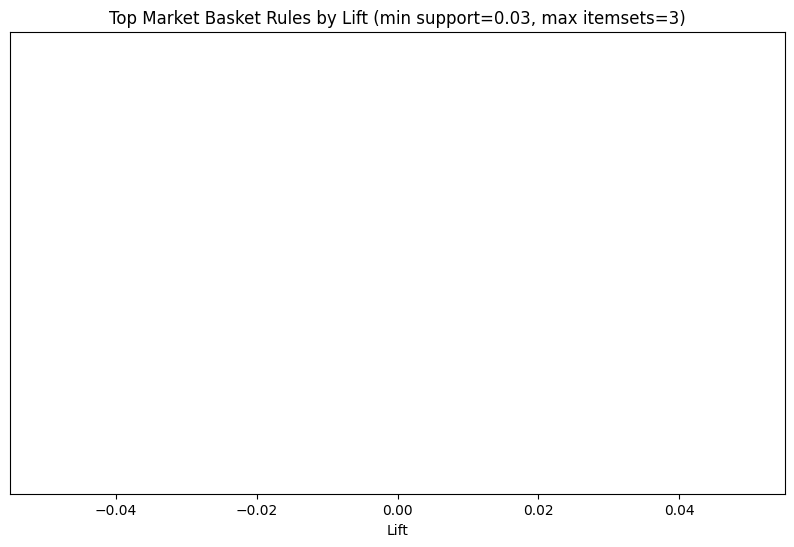

Generating rules with minimum support: 0.03 and max itemsets: 4


/Users/neehanth/Documents/Masters/Data Mining/E-commerce Customer Analytics/project_env/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets: 87
Number of rules generated: 0
Time taken: 0.29 seconds


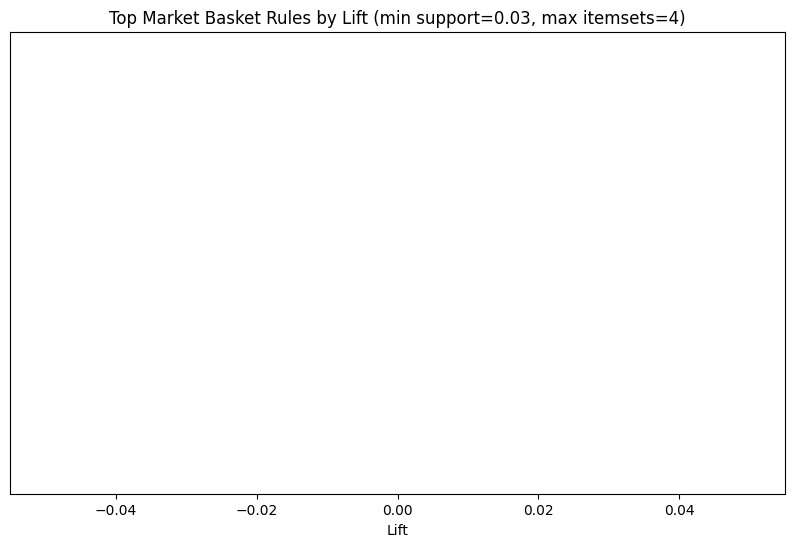

In [52]:
import time

for min_sup in [0.01, 0.02, 0.03]:
    for max_item_sets in [2, 3, 4]:
        print(f"Generating rules with minimum support: {min_sup} and max itemsets: {max_item_sets}")
        
        start_time = time.time()
        frequent_itemsets, rules = apriori_analysis(
            basket_sets,
            min_support=min_sup,
            min_threshold=1,
            max_items=max_item_sets
        )
        total_time = time.time() - start_time
        print(f"Number of frequent itemsets: {len(frequent_itemsets)}")
        print(f"Number of rules generated: {len(rules)}")
        print(f"Time taken: {total_time:.2f} seconds")
        
        top_rules = rules.head(10)

        plt.figure(figsize=(10, 6))
        plt.barh(range(len(top_rules)), top_rules['lift'], color='#003087')
        plt.yticks(range(len(top_rules)), [f"{row['antecedents']} -> {row['consequents']}" 
                                        for _, row in top_rules.iterrows()])
        plt.xlabel('Lift')
        plt.title(f'Top Market Basket Rules by Lift (min support={min_sup}, max itemsets={max_item_sets})')
        plt.gca().invert_yaxis()
        plt.show()

`Overview`:
The Apriori algorithm was run on the one‑hot encoded basket matrix using a range of minimum support thresholds and maximum itemset lengths.

`Results`:
| `min_support` | Max itemset length | Frequent itemsets | Rules generated | Runtime (sec) | Observations                                                                                                         |
| ------------- | ------------------ | ----------------- | --------------- | ------------- | -------------------------------------------------------------------------------------------------------------------- |
| **0.01**      | 2                  | 851               | 122             | 17.90         | Many frequent itemsets and rules; top rules involve *Regency Tea Plate* colour variants and toy room sets.           |
| **0.01**      | 3                  | 901               | 251             | 18.91         | Allowing three‑item sets increases the rule count; new rules combine three variants (e.g., pink + roses ⇒ green).    |
| **0.01**      | 4                  | 903               | 264             | 18.55         | Little change beyond three items, suggesting most frequent sets have ≤3 items.                                       |
| **0.02**      | 2                  | 232               | 20              | 1.22          | Raising support sharply reduces itemsets and rules; strongest rules now involve *Regency Teacup and Saucer* colours. |
| **0.02**      | 3                  | 233               | 25              | 1.22          | Three‑item rules emerge but are variants of the same teacup combinations.                                            |
| **0.02**      | 4                  | 233               | 25              | 1.16          | No additional multi‑item patterns beyond size 3.                                                                     |
| **0.03**      | 2                  | 87                | 0               | 0.28          | At 3 % support no rules meet the lift threshold; frequent itemsets exist but they are not predictive.                |
| **0.03**      | 3                  | 87                | 0               | 0.28          | Same as above.                                                                                                       |
| **0.03**      | 4                  | 87                | 0               | 0.29          | Same as above.                                                                                                       |

`Insights`:
* **With 1 % support, max‑itemset = 3**
    - Shoppers who buy Regency Tea Plate Green and Regency Tea Plate Roses, they almost always add the Regency Tea Plate Pink; similarly, purchasing any one colour of the Regency plates strongly predicts adding the other two.
    - Another cluster shows parents completing the Poppy’s Playhouse toy collection - buying the bedroom and kitchen sets together.
    - These high‑lift (>60) associations are rare but very strong.
* **With 2 % support, max‑itemset = 3**
    - The strongest rules now revolve around the Regency Teacup and Saucer line: customers who buy one colour (e.g. pink) often pick up the other colours (green and roses) in the same order. The lift values are lower (around 20) because these products are popular, but the patterns are still meaningful.
    - A few other pairings emerge, such as Spaceboy and Dolly Girl lunch boxes or different Gardeners Kneeling Pad designs, suggesting complementary or substitute products within these categories.

`Recommendations`:
1. **Bundle and promote complementary items**: The high-lift combinations - such as customers buying all three Regency Tea Plate colours together or completing Poppy’s Playhouse room sets - lend themselves to multi‑item discounts and “complete the set” promotions.
    - Client could offer a discounted trio of pink, green and roses tea plates or a bundled price for all three Poppy’s Playhouse rooms.
2. **Optimize product placement and recommendations**: Place the strongly associated items adjacent to each other on shelves or group them together on the product detail page.
    - Online, incorporate “Complete your tea set with…” or “People also bought…” recommendations.
3. **Coordinate inventory and stocking** Because these products drive each other’s demand, ensure that complementary items are in stock together. Knowing which items boost each other’s sales helps retailers forecast inventory more accurately and avoid out‑of‑stock situations.

## 3. Sales Forecasting

### 3.1 Data Preparation and EDA

In [259]:
# Plot the time series data
time_data = (cleaned_data
             .assign(Revenue = cleaned_data['Quantity'] * cleaned_data['UnitPrice'])
             .set_index("InvoiceDate")
            )
time_data.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,TotalPrice,Revenue
InvoiceDate,,,,,,,,,
2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,20.34,20.34
2010-12-01 08:26:00,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,7.65,17850.0,United Kingdom,15.30,15.30
2010-12-01 08:26:00,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25,17850.0,United Kingdom,25.50,25.50
2010-12-01 08:28:00,536366,22633,HAND WARMER UNION JACK,6,1.85,17850.0,United Kingdom,11.10,11.10
2010-12-01 08:28:00,536366,22632,HAND WARMER RED POLKA DOT,6,1.85,17850.0,United Kingdom,11.10,11.10


**Which market should we model?**

In [260]:
# Which countries generate the most money?
country_revenue = (time_data
                   .groupby('Country', as_index=False)['Revenue']
                   .sum()
                   .sort_values('Revenue', ascending=False))

country_revenue.head(10)

,Country,Revenue
35,United Kingdom,6623368.433
23,Netherlands,269330.180
10,EIRE,242698.340
14,Germany,190201.940
13,France,173532.120
0,Australia,134070.620
32,Switzerland,48109.330
30,Spain,43046.190
19,Japan,35975.170
31,Sweden,35128.050


`Insights`: Most of the revenue is generated by customers from *United Kingdom*.

In [261]:
# Top countries by quantity sold
country_quantity = (time_data
                    .groupby('Country', as_index=False)['Quantity']
                    .sum()
                    .sort_values('Quantity', ascending=False))

country_quantity.head(10)

,Country,Quantity
35,United Kingdom,3894948
23,Netherlands,192799
10,EIRE,131220
14,Germany,111639
13,France,106432
0,Australia,81787
31,Sweden,35316
32,Switzerland,27846
19,Japan,25356
30,Spain,23101


`Insights`: So the rankings for the countries are similar to the top 10 countries by revenue, except for the country Spain.

In [262]:
# How many customers and orders each country has?
country_activity = (time_data
    .groupby('Country')
    .agg(
        Revenue=('Revenue', 'sum'),
        Quantity=('Quantity', 'sum'),
        Num_Invoices=('InvoiceNo', 'nunique'),
        Num_Customers=('CustomerID', 'nunique')
    )
    .sort_values('Revenue', ascending=False)
)

country_activity.head(10)

,Revenue,Quantity,Num_Invoices,Num_Customers
Country,,,,
United Kingdom,6623368.433,3894948,16417,3896
Netherlands,269330.180,192799,92,9
EIRE,242698.340,131220,254,3
Germany,190201.940,111639,441,94
France,173532.120,106432,376,87
Australia,134070.620,81787,56,9
Switzerland,48109.330,27846,47,21
Spain,43046.190,23101,87,30
Japan,35975.170,25356,19,8


In [263]:
total_revenue = country_activity["Revenue"].sum()
uk_revenue = country_activity.loc["United Kingdom", "Revenue"]

print(f"Total revenue = {total_revenue:.2f}")
print(f"UK revenue = {uk_revenue:.2f}")
print(f"UK revenue share = {((total_revenue - uk_revenue) / uk_revenue)*100:.2f}")

Total revenue = 8015349.54
UK revenue = 6623368.43
UK revenue share = 21.02


`Insights`:
The United Kingdom accounts for 21% of total revenue, with 3896 unique customers and 16417 invoices, making it the primary market.

Since the United Kingdom generates the majority of revenue and has the highest number of customers and invoices, all subsequent sales forecasting will focus on UK daily revenue.

In [264]:
# UK-only dataset
uk_data = time_data[time_data['Country'] == 'United Kingdom'].copy()
uk_data = uk_data.sort_values('InvoiceDate')
uk_data.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,TotalPrice,Revenue
InvoiceDate,,,,,,,,,
2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,20.34,20.34
2010-12-01 08:26:00,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,7.65,17850.0,United Kingdom,15.30,15.30
2010-12-01 08:26:00,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25,17850.0,United Kingdom,25.50,25.50
2010-12-01 08:28:00,536366,22633,HAND WARMER UNION JACK,6,1.85,17850.0,United Kingdom,11.10,11.10
2010-12-01 08:28:00,536366,22632,HAND WARMER RED POLKA DOT,6,1.85,17850.0,United Kingdom,11.10,11.10


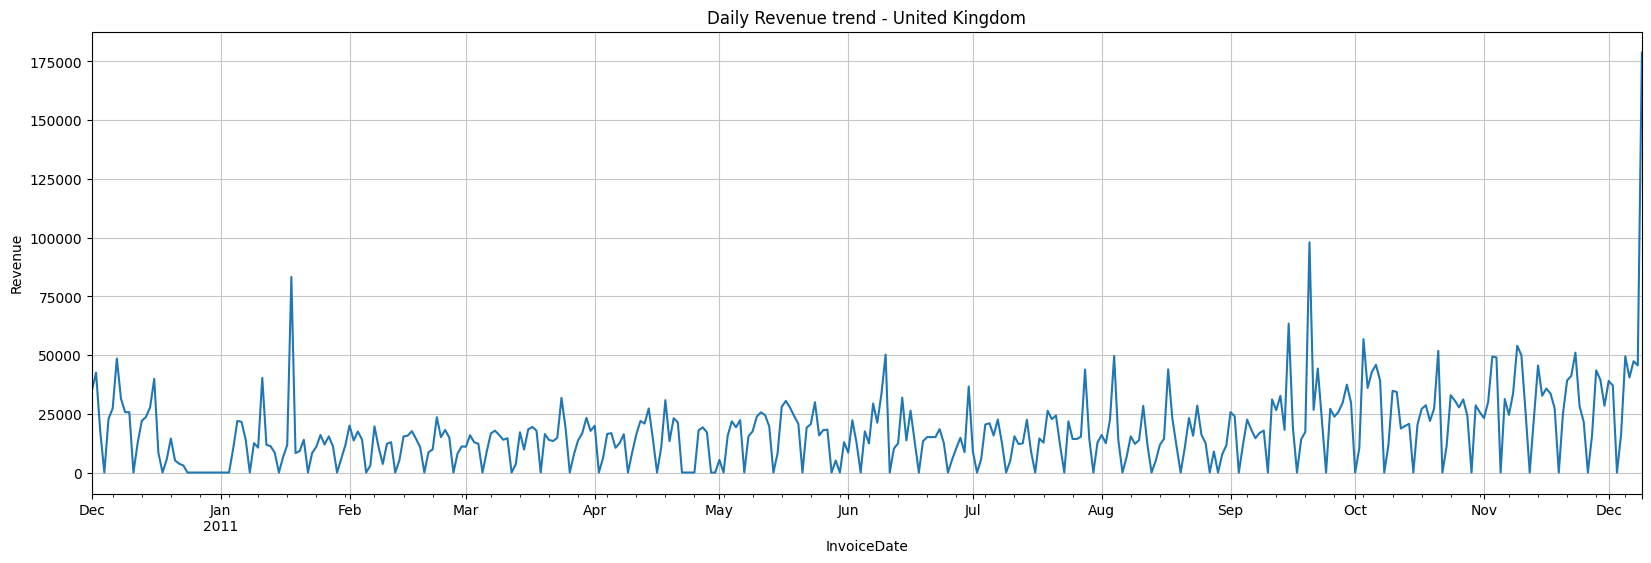

In [265]:
uk_daily_revenue = (
    uk_data
    .resample('D')['Revenue']
    .sum()
)

plt.figure(figsize=(20, 6))
uk_daily_revenue.plot()
plt.title("Daily Revenue trend - United Kingdom")
plt.ylabel("Revenue")
plt.grid(color="#C6C6C6")
plt.show()

`Insights`: Revenue is relatively stable for the first 8 months, but shifts into a clear upward trend starting in September, driven by increased activity leading into the holidays.

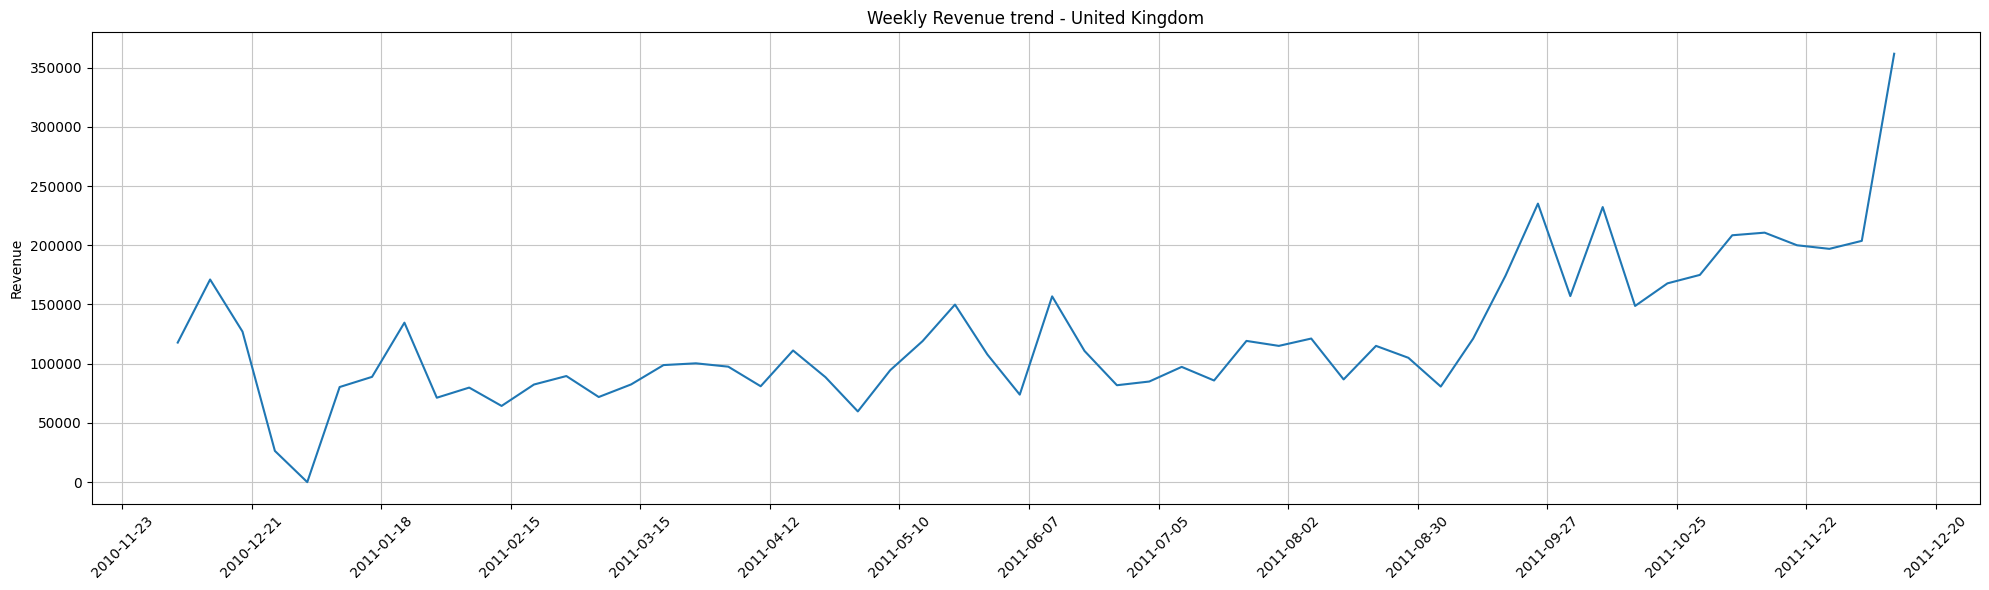

In [ ]:
import matplotlib.dates as mdates

uk_weekly_revenue = (
    uk_data
    .resample('W')['Revenue']
    .sum()
)

fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(uk_weekly_revenue.index, uk_weekly_revenue.values)

ax.set_title("Weekly Revenue trend - United Kingdom")
ax.set_ylabel("Revenue")
ax.grid(color="#C6C6C6")

# Tick every Nth week (interval=1 for every week, 2 for every 2nd week, etc.)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=4))  # every 4th week
# ax.xaxis.set_major_formatter(mdates.DateFormatter('Week %U'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

`Insights`: Following an extreme seasonal decline in January, the business stabilizes through the middle of the year before beginning an interesting growth trend in late Q3.  As the business takes advantage of the busiest holiday trading season, this momentum picks up speed and leads to in a huge revenue increase in the Q4.

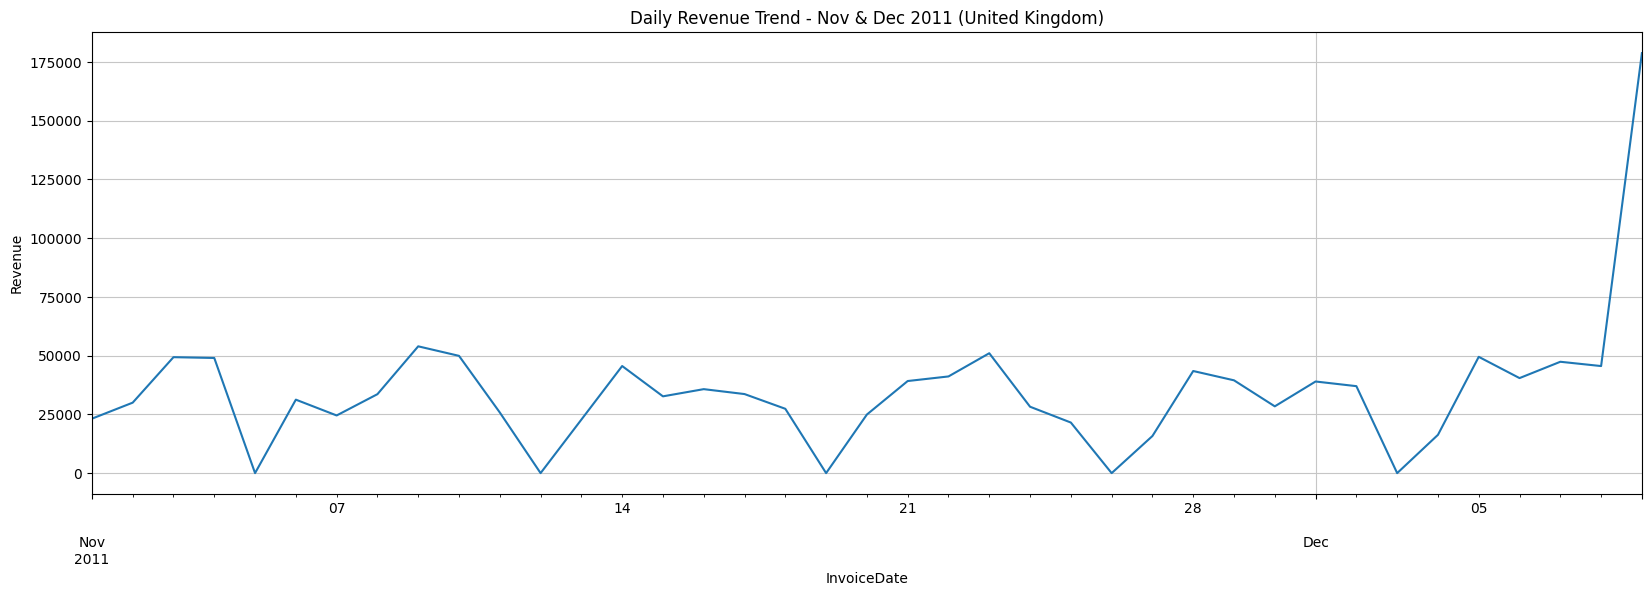

In [145]:
# Filter data for November and December 2011
uk_december_2011 = uk_data.loc['2011-11-01':max(uk_data.index)]

uk_daily_revenue_december = uk_december_2011.resample('D')['Revenue'].sum()

plt.figure(figsize=(20, 6))
uk_daily_revenue_december.plot()
plt.title("Daily Revenue Trend - Nov & Dec 2011 (United Kingdom)")
plt.ylabel("Revenue")
plt.grid(color="#C6C6C6")
plt.show()

`Insights`:
* **Steady Rhythm in November:** throughout November, the business holds a consistent "heartbeat," with regular weekly peaks hovering around **50,000** and standard drops on weekends.
* **The December Anomaly:** The chart is defined by a massive outlier in the second week of December. Revenue skyrockets to nearly **175,000** in a single day, shattering previous trends.
    * This sudden vertical spike suggests a specific event rather than organic growth—likely a massive bulk order or a final "shipping cutoff" rush before the holidays.

In [40]:
uk_ts = uk_daily_revenue.to_frame(name='Revenue')
uk_ts['day_of_week'] = uk_ts.index.dayofweek
uk_ts['month'] = uk_ts.index.month

# Average revenue by day of week
dow_avg = uk_ts.groupby('day_of_week')['Revenue'].mean()
dow_avg.rename({0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}, inplace=True)

# Average revenue by month
month_avg = uk_ts.groupby('month')['Revenue'].mean()
month_avg.rename(
    {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
     7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'},
     inplace=True
)

print("Average revenue by day of week:")
print(dow_avg)

print("\nAverage revenue by month:")
print(month_avg)

Average revenue by day of week:
day_of_week
Mon    18949.515472
Tue    24346.921340
Wed    21388.347222
Thu    26205.390741
Fri    20919.402796
Sat        0.000000
Sun    11866.937377
Name: Revenue, dtype: float64

Average revenue by month:
month
Jan    12476.570323
Feb    11269.125000
Mar    13348.690000
Apr    12037.268700
May    15791.907419
Jun    16022.718667
Jul    13935.099065
Aug    14426.868387
Sep    24622.838700
Oct    24512.249032
Nov    30058.848000
Dec    22408.745000
Name: Revenue, dtype: float64


`Insights`:
- Thursdays are the top performer, leading a busy mid-week peak, while the business appears to be completely inactive on Saturdays.
- November is the top month, with revenue far greater than in the first half of the year and a huge fourth-quarter jump.

### 3.2 Stationarity Check (for SARIMA)

A time series is **stationary** if its statistical properties (mean, variance, and autocorrelation) remain constant over time rather than drifting with trends or seasonality.

Because **SARIMA assumes stationarity**, we must first confirm whether the original daily/weekly UK revenue series is stationary; if it is not, we need to difference it (and possibly seasonally difference it) until it becomes stable.

To check this, we:
- Visually inspect the **time-series plot** for trend and seasonality ([data-preparation-and-eda](#data-preparation-and-eda)).
- Apply the **Augmented Dickey–Fuller (ADF) test** on:
  - the original daily revenue series, and
  - one or more differenced versions (e.g., first difference and seasonal difference with lag 7).  

If the ADF **p-value drops below 0.05** after differencing, we treat the differenced series as stationary and use that in our **SARIMA model** (with the corresponding differencing orders `d` and `D`).

In [41]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name="", alpha=0.05):
    """
    Run Augmented Dickey-Fuller test and print a compact summary.
    
    Args:
        series (pd.Series): Time series to test (index = datetime, values = numeric).
        name (str): Label for the series (for printing).
        alpha (float): Significance level (default 0.05).
    """
    series_clean = series.dropna()
    result = adfuller(series_clean)
    labels = ["ADF Test Statistic", "p-value", "#Lags used", "#Observations used"]

    print(f"\n=== ADF Test: {name} ===")
    for value, label in zip(result, labels):
        print(f"{label} : {str(value)}")
    
    if result[1] < alpha:
        print(f"Conclusion: Stationary at ⍺={alpha}.")
    else:
        print(f"Conclusion: Non-stationary at α={alpha}.")

In [42]:
# Run the ADF test on both daily and weekly revenue series
uk_daily_revenue_df = pd.DataFrame(uk_daily_revenue)

adf_test(uk_daily_revenue_df["Revenue"], name="UK Daily Revenue")


=== ADF Test: UK Daily Revenue ===
ADF Test Statistic : -0.3496511795109954
p-value : 0.9181719271993363
#Lags used : 13
#Observations used : 360
Conclusion: Non-stationary at α=0.05.


`Insights`:
Given the clear trend and weekly seasonal pattern in daily UK revenue, and the non-stationary ADF result on the raw series,
1. first difference once at the non-seasonal level (d = 1) and once at the weekly seasonal level with period 7 (D = 1, s = 7).
2. Check for the stationarity and once the data is stationary,
3. then fit SARIMA model and forecast the future revenue.

In [43]:
# First difference (d = 1)
daily_diff = uk_daily_revenue_df.diff().dropna()
adf_test(daily_diff, name="UK Daily Revenue - 1st Difference")

# Seasonal difference (D = 1, s = 7)
daily_seasonal_diff = uk_daily_revenue_df.diff(7).dropna()
adf_test(daily_seasonal_diff, name="UK Daily Revenue - Seasonal Diff (lag 7)")


=== ADF Test: UK Daily Revenue - 1st Difference ===
ADF Test Statistic : -5.854713076225366
p-value : 3.5221103088252604e-07
#Lags used : 12
#Observations used : 360
Conclusion: Stationary at ⍺=0.05.

=== ADF Test: UK Daily Revenue - Seasonal Diff (lag 7) ===
ADF Test Statistic : -6.868066032986801
p-value : 1.5407614017315186e-09
#Lags used : 6
#Observations used : 360
Conclusion: Stationary at ⍺=0.05.


### 3.3 Differencing Decision for Daily UK Revenue

- **First Differencing (d):**  
  Although first differencing makes the series stationary according to the ADF test, we **do not apply regular differencing initially** and set **d = 0**, to avoid over-differencing given we only have about one year of data.

- **Seasonal Differencing (D):**  
  Because the daily UK revenue shows a strong **weekly pattern** and the ADF test on the seasonal difference (lag 7) also indicates stationarity, we **apply one seasonal difference with period 7**, setting **D = 1, s = 7**.

Based on this, we model the series using **SARIMA(p, 0, q)(P, 1, Q, 7)**.

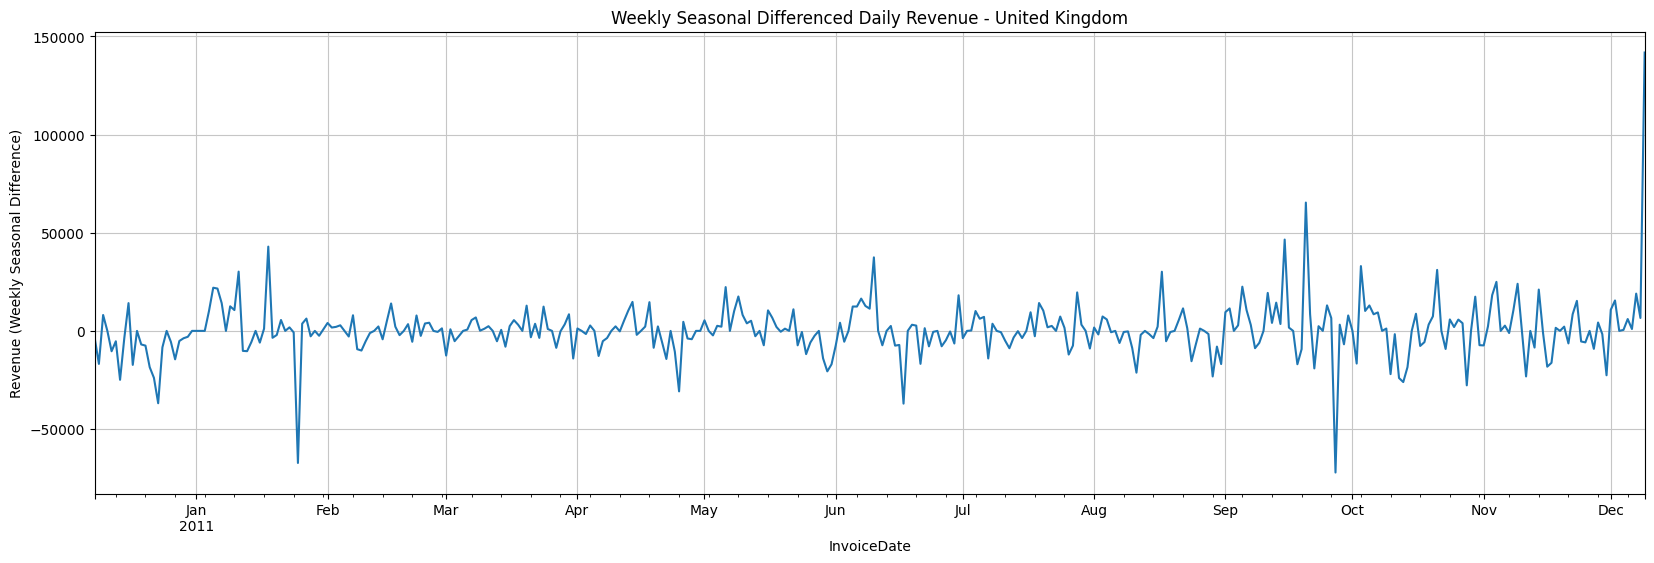

In [44]:
uk_daily_revenue_df["Revenue_WeeklySeasonalDiff"] = uk_daily_revenue_df["Revenue"].diff(7)

plt.figure(figsize=(20, 6))
uk_daily_revenue_df["Revenue_WeeklySeasonalDiff"].dropna().plot()
plt.title("Weekly Seasonal Differenced Daily Revenue - United Kingdom")
plt.ylabel("Revenue (Weekly Seasonal Difference)")
plt.grid(color="#C6C6C6")
plt.show()

### 3.4 Choosing How Many Previous Days to Use (AR / MA Orders)

To decide **how many past days the model should look at** when predicting today’s revenue, we don’t guess — we inspect the **autocorrelation structure** of the *stationary* series (here: the weekly-seasonally differenced daily revenue).

Use two diagnostic plots:

- **ACF (Autocorrelation Function)**  
  - Shows how today’s value is correlated with values at lag 1, 2, 3, ...  
  - Helps identify **MA terms (q, Q)**.  
  - A sharp cutoff after lag *k* suggests an MA(k) component.

- **PACF (Partial Autocorrelation Function)**  
  - Shows the correlation between today’s value and a past value at lag *k*, after removing the effects of the intermediate lags.  
  - Helps identify **AR terms (p, P)**.  
  - A sharp cutoff after lag *k* suggests an AR(k) component.

In practice:
1. Compute ACF and PACF on the **weekly-seasonally differenced daily revenue** series.
2. Look for where the significant spikes (outside the confidence band) **cut off or start to tail off**.
3. Use those lags as initial guesses for `(p, q)` and seasonal `(P, Q)` in the SARIMA(p, 0, q)(P, 1, Q, 7) model.

This way, the number of “previous days” the model uses is **data-driven**, based on observed autocorrelation patterns rather than arbitrary choice.

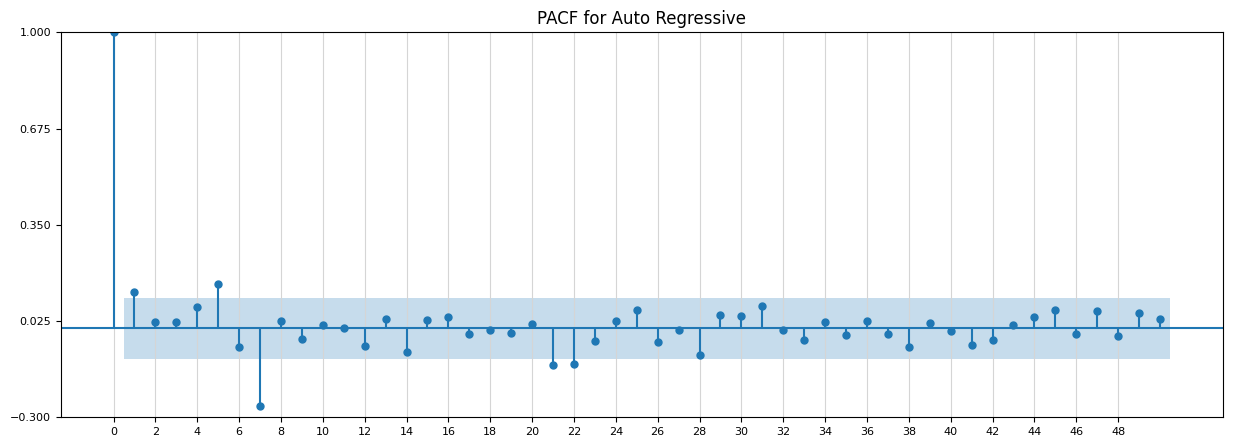

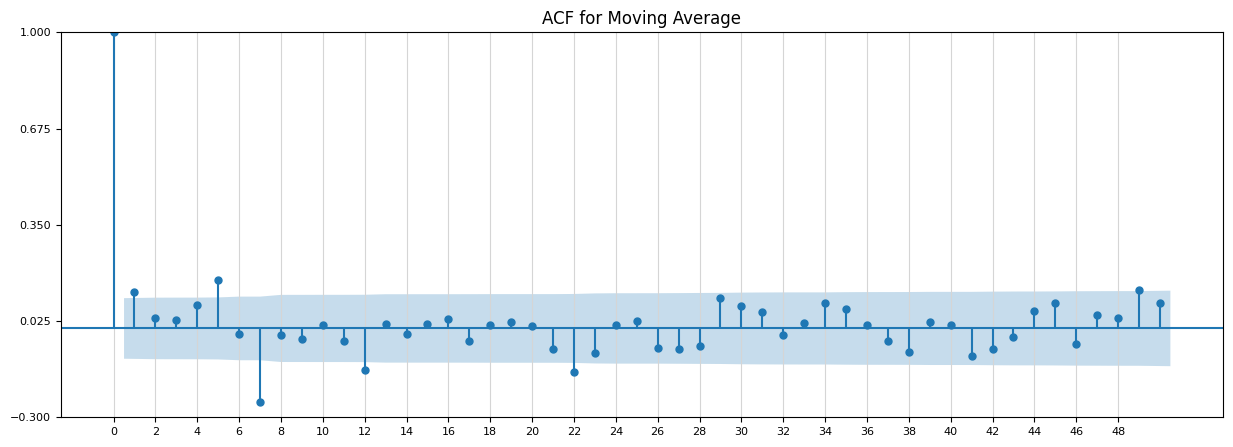

In [45]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = uk_daily_revenue_df["Revenue_WeeklySeasonalDiff"].dropna()

yticks = np.linspace(-0.3, 1, 5)
xticks = np.arange(0, 50, 2)

# PACF
fig_pacf, ax_pacf = plt.subplots(figsize=(15, 5))
plot_pacf(series, lags=50, ax=ax_pacf)
ax_pacf.set_title("PACF for Auto Regressive")
ax_pacf.set_ylim(-0.3, 1)
ax_pacf.set_yticks(yticks)
ax_pacf.set_xticks(xticks)
ax_pacf.tick_params(axis='y', labelsize=8)
ax_pacf.tick_params(axis='x', labelsize=8)
plt.grid(axis='x', color="#D5D5D5")
plt.show()

# ACF
fig_acf, ax_acf = plt.subplots(figsize=(15, 5))
plot_acf(series, lags=50, ax=ax_acf)
ax_acf.set_title("ACF for Moving Average")
ax_acf.set_ylim(-0.3, 1)
ax_acf.set_yticks(yticks)
ax_acf.set_xticks(xticks)
ax_acf.tick_params(axis='y', labelsize=8)
ax_acf.tick_params(axis='x', labelsize=8)
plt.grid(axis='x', color="#D5D5D5")
plt.show()

`Insights`:
- At **non-seasonal lags** (1–6), both ACF and PACF show clear spikes at **lag 1** that quickly die out, suggesting a **low-order AR and MA component** -> we set **p = 1** and **q = 1**.
- At the **seasonal lag** 7, the PACF has a strong spike while later seasonal lags are small, indicating a **seasonal AR(1)** term with weekly period 7 → we set **P = 1**, **Q = 0**, **s = 7**.
- Using our earlier differencing choice (**d = 0**, **D = 1**, **s = 7**), this leads to the model:
    
    `SARIMA(1, 0, 1)(1, 1, 0, 7)` 
    
    for daily UK revenue.

In [ ]:
# Fit SARIMA model
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

y = (
    uk_daily_revenue_df
    .sort_index()
    .asfreq('D')
)

# Train-test split
split_date = pd.to_datetime("2011-09-01")
train = y.loc[:split_date]
test  = y.loc[split_date + pd.Timedelta(days=1):]

print(f"Train data size: {len(train)} | Test data size: {len(test)}")

Train data size: 275 | Test data size: 99


In [54]:
# Fit SARIMA
model = SARIMAX(
    train["Revenue"],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            Revenue   No. Observations:                  275
Model:             SARIMAX(1, 0, 1)x(1, 1, [], 7)   Log Likelihood               -2753.583
Date:                            Fri, 28 Nov 2025   AIC                           5515.166
Time:                                    10:39:20   BIC                           5529.409
Sample:                                12-01-2010   HQIC                          5520.892
                                     - 09-01-2011                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7791      0.156      5.009      0.000       0.474       1.084
ma.L1         -0.5779      0.190     -3.049      0.002      -0.949      -0.206
ar.S.L7       -0.3392      0.035     -9.686      0.000      -0.408      -0.271
sigma2      1.049e+08   5.84e-10    1.8e+17      0.000    1.05e+08    1.05e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               496.74
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.61   Skew:                             0.10
Prob(H) (two-sided):                  0.02   Kurtosis:                         9.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.28e+33. Standard errors may be unstable.
"""

In [ ]:
# Forecast over the test period
n_steps = len(test)
forecast_res = results.get_forecast(steps=n_steps)
pred = forecast_res.predicted_mean
pred_ci = forecast_res.conf_int()

# Align index with test data
pred.index = test.index
pred_ci.index = test.index

In [65]:
# Evaluate
mse = mean_squared_error(test["Revenue"], pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test["Revenue"], pred)
print(f"RMSE: {rmse:,.2f}")
print(f"MAE : {mae:,.2f}")

RMSE: 28,060.27
MAE : 19,015.86


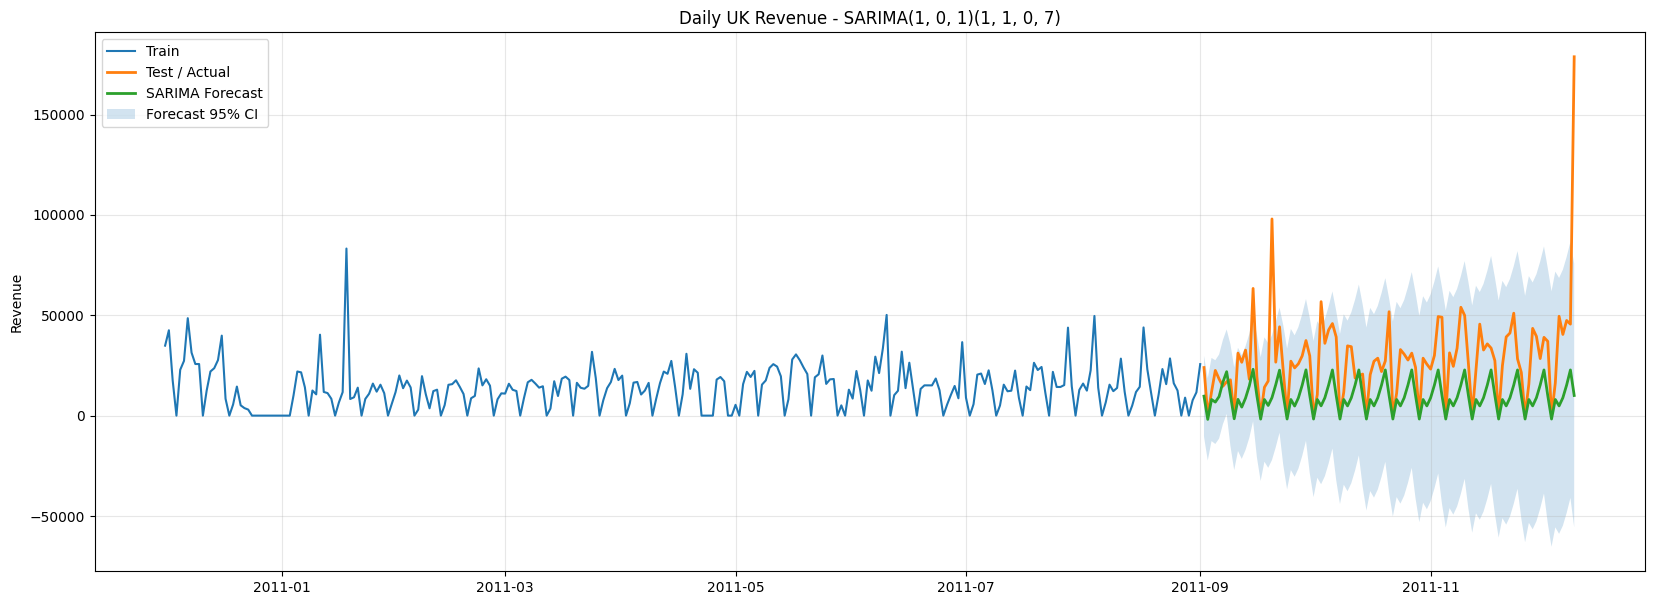

In [74]:
# Plot actual vs forecast with confidence intervals
plt.figure(figsize=(20, 7))
plt.plot(train.index, train["Revenue"], label="Train")
plt.plot(test.index, test["Revenue"], label="Test / Actual", linewidth=2)
plt.plot(pred.index, pred, label="SARIMA Forecast", linewidth=2)

plt.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    alpha=0.2,
    label="Forecast 95% CI"
)

plt.title("Daily UK Revenue - SARIMA(1, 0, 1)(1, 1, 0, 7)")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

`Insights`: This model captures the regular weekly pattern in UK daily revenue but **systematically underestimates the large Q4 sales spikes**, especially the extreme holiday peak. This leads to a high forecast error on the test period, even though the average pattern is modeled reasonably well.

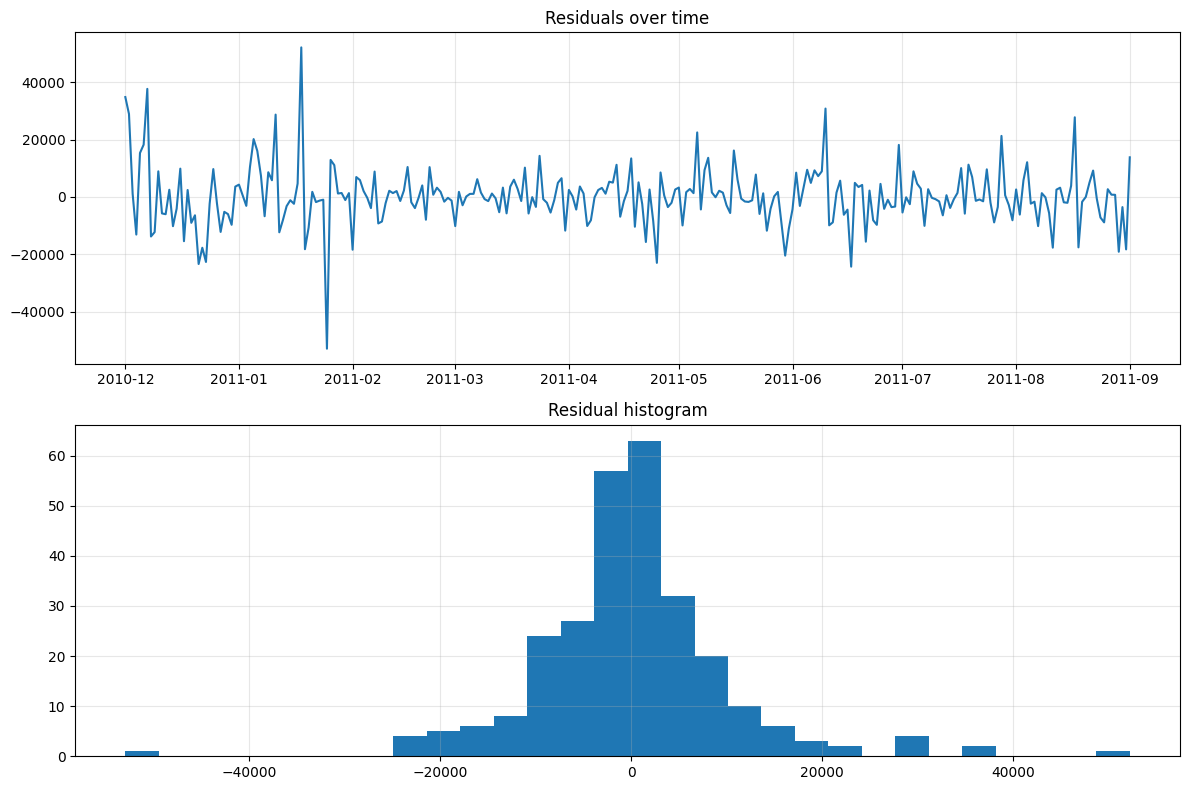

In [ ]:
# Check residuals of the current SARIMA model
resid = results.resid
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes = axes.ravel()

axes[0].plot(resid)
axes[0].set_title("Residuals over time")
axes[0].grid(alpha=0.3)

axes[1].hist(resid, bins=30)
axes[1].set_title("Residual histogram")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [107]:
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(resid, lags=[7, 14, 21], return_df=True)
print("Ljung-Box test results:")
print(lb)

Ljung-Box test results:
      lb_stat  lb_pvalue
7   14.570538   0.041916
14  39.629765   0.000291
21  55.917475   0.000052


`Insights`:
* p-values < 0.05 --> residuals are not white noise at those lags.
    - there is still autocorrelation at weekly multiples (7, 14, 21 days) that the current model isn’t fully capturing.

In [124]:
# Try a slightly richer SARIMA: add non-seasonal differencing
def evaluate_sarima(train, test, order, seasonal_order):
    """
    Fit SARIMA on train, forecast test, and return AIC, RMSE, MAE.
    """
    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    
    n_steps = len(test)
    fc = res.get_forecast(steps=n_steps)
    pred = fc.predicted_mean
    pred.index = test.index
    
    mse = mean_squared_error(test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(test, pred)
    return {
        "order": order,
        "seasonal_order": seasonal_order,
        "AIC": res.aic,
        "RMSE": rmse,
        "MAE": mae
    }

# candidates = [
#     ((1, 0, 1), (1, 1, 0, 7)),
#     ((1, 1, 1), (1, 1, 0, 7)),
#     ((0, 1, 1), (1, 1, 0, 7)),
#     ((1, 1, 0), (1, 1, 0, 7)),
# ]

candidates = [
    # current best neighbourhood
    ((1, 0, 1), (1, 1, 0, 7)),
    
    # try higher AR at lag 5
    ((5, 0, 1), (1, 1, 0, 7)),
    ((5, 0, 0), (1, 1, 0, 7)),
    
    # try higher MA at lag 5
    ((1, 0, 5), (1, 1, 0, 7)),
    ((0, 0, 5), (1, 1, 0, 7)),
    
    # slightly richer but still reasonable
    ((2, 0, 2), (1, 1, 0, 7)),
    ((2, 0, 1), (1, 1, 0, 7)),
    ((1, 0, 2), (1, 1, 0, 7)),
]

results_list = []
# for order, seas in candidates:
#     stats = evaluate_sarima(train["Revenue"], test["Revenue"], order, seas)
#     results_list.append(stats)
#     print(f"Model Order: {order}, Seasonal Order: {seas}")
#     print(f"AIC: {stats['AIC']:.2f} | RMSE: {stats['RMSE']:.2f} | MAE: {stats['MAE']:.2f}")
#     print("-" * 50)

for order, seas in candidates:
    try:
        stats = evaluate_sarima(train["Revenue"], test["Revenue"], order, seas)
        results_list.append(stats)
        print(f"Model Order: {order}, Seasonal Order: {seas}")
        print(f"AIC: {stats['AIC']:.2f} | RMSE: {stats['RMSE']:.2f} | MAE: {stats['MAE']:.2f}")
        print("-" * 50)
    except Exception as e:
        print(f"Model {order}, {seas} failed to converge: {e}")

Model Order: (1, 0, 1), Seasonal Order: (1, 1, 0, 7)
AIC: 5515.17 | RMSE: 28060.27 | MAE: 19015.86
--------------------------------------------------
Model Order: (5, 0, 1), Seasonal Order: (1, 1, 0, 7)
AIC: 5434.25 | RMSE: 28478.09 | MAE: 19774.84
--------------------------------------------------
Model Order: (5, 0, 0), Seasonal Order: (1, 1, 0, 7)
AIC: 5432.13 | RMSE: 28479.34 | MAE: 19776.36
--------------------------------------------------
Model Order: (1, 0, 5), Seasonal Order: (1, 1, 0, 7)
AIC: 5515.52 | RMSE: 27921.27 | MAE: 19119.53
--------------------------------------------------
Model Order: (0, 0, 5), Seasonal Order: (1, 1, 0, 7)
AIC: 5535.20 | RMSE: 27807.51 | MAE: 19027.21
--------------------------------------------------
Model Order: (2, 0, 2), Seasonal Order: (1, 1, 0, 7)
AIC: 5466.96 | RMSE: 25108.47 | MAE: 15639.22
--------------------------------------------------
Model Order: (2, 0, 1), Seasonal Order: (1, 1, 0, 7)
AIC: 5512.47 | RMSE: 26297.68 | MAE: 16958.68
-

`Insights`: Among several nearby SARIMA specifications, the model with orders `(1, 0, 1)(1, 1, 0, 7)` achieves the lowest forecast error on the test set, even though residual diagnostics indicate some remaining seasonal autocorrelation.

RMSE: 25,108.47
MAE : 15,639.22


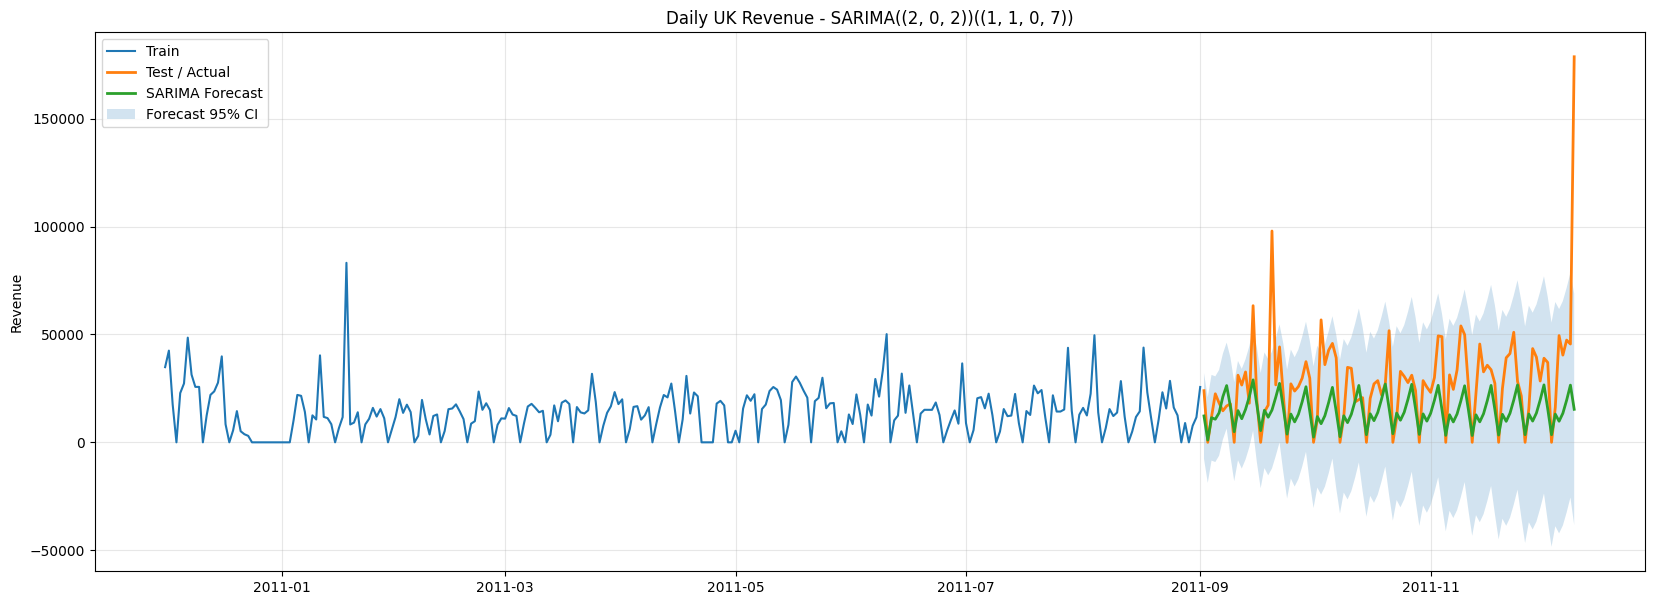

In [127]:
best_order = (2, 0, 2)
best_seasonal = (1, 1, 0, 7)

# Fit SARIMA
best_model = SARIMAX(
    train["Revenue"],
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_model_results = best_model.fit()

# Forecast over the test period
n_steps = len(test)
best_forecast_res = best_model_results.get_forecast(steps=n_steps)
best_pred = best_forecast_res.predicted_mean
best_pred_ci = best_forecast_res.conf_int()

# Align index with test data
best_pred.index = test.index
best_pred_ci.index = test.index

# Evaluate
best_mse = mean_squared_error(test["Revenue"], best_pred)
best_rmse = np.sqrt(best_mse)
best_mae = mean_absolute_error(test["Revenue"], best_pred)
print(f"RMSE: {best_rmse:,.2f}")
print(f"MAE : {best_mae:,.2f}")

# Plot actual vs forecast with confidence intervals
plt.figure(figsize=(20, 7))
plt.plot(train.index, train["Revenue"], label="Train")
plt.plot(test.index, test["Revenue"], label="Test / Actual", linewidth=2)
plt.plot(best_pred.index, best_pred, label="SARIMA Forecast", linewidth=2)

plt.fill_between(
    best_pred_ci.index,
    best_pred_ci.iloc[:, 0],
    best_pred_ci.iloc[:, 1],
    alpha=0.2,
    label="Forecast 95% CI"
)

plt.title(f"Daily UK Revenue - SARIMA({best_order})({best_seasonal})")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

`Insights`: Finally selected **SARIMA(2, 0, 2)(1, 1, 0, 7)** on UK daily revenue, which models:
- **Non-seasonal AR(2) and MA(2)** terms to capture short-term dependence across the last few days.
- - **Seasonal AR(1) with weekly period `s = 7` and seasonal differencing `D = 1`**, to capture the strong day-of-week pattern in UK sales.

On the held-out test window (Sep–Dec 2011), this model achieves:
- **RMSE ≈ 25,108**
- **MAE ≈ 15,639**

This is a clear improvement over the simpler SARIMA(1,0,1)(1,1,0,7) baseline (≈28k RMSE / 19k MAE).

Overall, SARIMA(2,0,2)(1,1,0,7) is a reasonable **short-term forecasting model for UK daily e-commerce revenue**, capturing both trend and weekly seasonality with lower forecast error.

### 3.5 Short-Term Forecast

                 Forecast      Lower_95       Upper_95
2011-12-10   18227.708613 -10534.677974   46990.095199
2011-12-11   29978.819935   1016.947411   58940.692458
2011-12-12   56867.655166  27783.799750   85951.510583
2011-12-13   45740.078880  16591.243294   74888.914466
2011-12-14   42143.131241  12967.101680   71319.160801
2011-12-15   41602.723833  12420.221797   70785.225868
2011-12-16  120620.003658  91437.494716  149802.512601
2011-12-17    4155.832037 -29802.049590   38113.713665
2011-12-18   15381.747844 -18594.562867   49358.058556
2011-12-19   42824.264773   8846.987495   76801.542051
2011-12-20   31060.646680  -2920.723969   65042.017328
2011-12-21   30431.417103  -3571.983679   64434.817884
2011-12-22   28762.963907  -5289.487552   62815.415366
2011-12-23  127994.573389  93862.235481  162126.911297
2011-12-24   -5101.499226 -44290.133912   34087.135461
2011-12-25    6662.995329 -32528.350508   45854.341165
2011-12-26   34495.575738  -4715.407027   73706.558504
2011-12-27

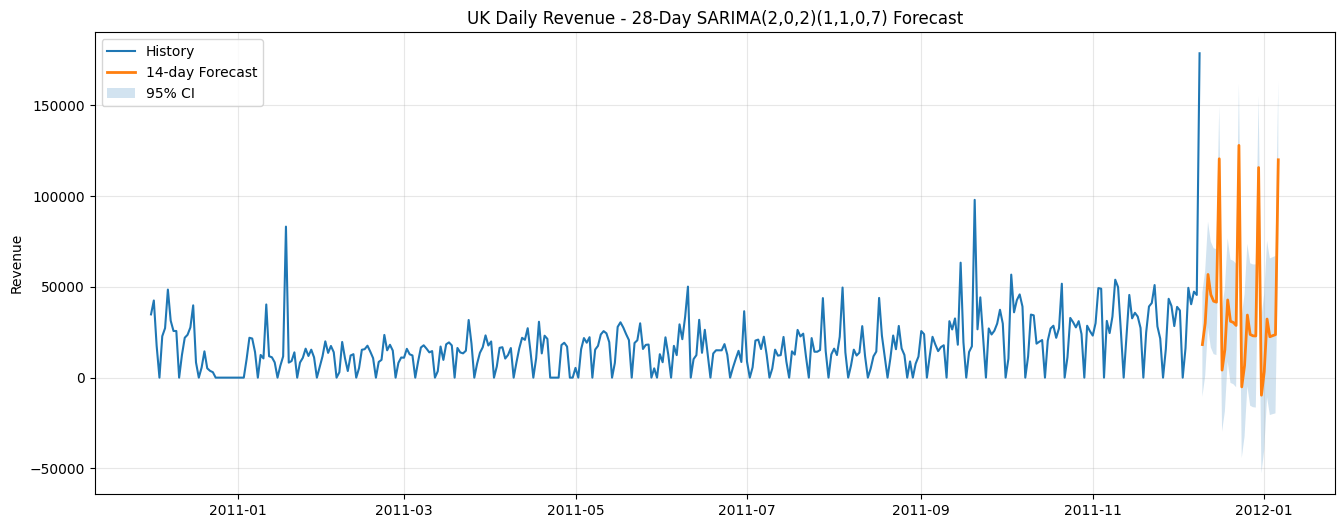

In [ ]:
# ----- Forecast future revenue -----
# y_daily is your daily UK revenue series with a DatetimeIndex
y_daily = uk_daily_revenue_df["Revenue"].sort_index()

# Fit the final SARIMA model
model_202 = SARIMAX(
    y_daily,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results_202 = model_202.fit(disp=False)

# Forecast future revenue
n_steps = 28
future_fc = results_202.get_forecast(steps=n_steps)
future_mean = future_fc.predicted_mean
future_ci = future_fc.conf_int()

# Nicely formatted forecast table
future_forecast = pd.DataFrame({
    "Forecast": future_mean,
    "Lower_95": future_ci.iloc[:, 0],
    "Upper_95": future_ci.iloc[:, 1],
})
print(future_forecast)

# Optional: plot
plt.figure(figsize=(16, 6))
plt.plot(y_daily.index, y_daily, label="History")
plt.plot(future_mean.index, future_mean, label="14-day Forecast", linewidth=2)

plt.fill_between(
    future_ci.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.2,
    label="95% CI"
)

plt.title(f"UK Daily Revenue - {n_steps}-Day SARIMA(2,0,2)(1,1,0,7) Forecast")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [146]:
from prophet import Prophet

# Prepare daily UK revenue for Prophet
uk_daily = (
    uk_daily_revenue_df["Revenue"]
    .sort_index()
    .asfreq("D")
    .fillna(0)
)

df = uk_daily.reset_index()
df.columns = ["ds", "y"]      # Prophet naming convention

# Train–test split (same date as SARIMA)
split_date = pd.to_datetime("2011-09-01")
train_df = df[df["ds"] <= split_date]
test_df  = df[df["ds"] > split_date]

print(train_df.shape, test_df.shape)

Importing plotly failed. Interactive plots will not work.


(275, 2) (99, 2)


In [147]:
m = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.5,
)

m.fit(train_df)

12:29:53 - cmdstanpy - INFO - Chain [1] start processing
12:29:54 - cmdstanpy - INFO - Chain [1] done processing


In [149]:
# Build future dataframe up to end of test period
future = m.make_future_dataframe(
    periods=len(test_df),
    freq="D"
)
forecast = m.predict(future)

# Align predictions with test period
pred_prophet = forecast.set_index("ds")["yhat"].loc[test_df["ds"]]

rmse_prophet = np.sqrt(mean_squared_error(test_df["y"], pred_prophet))
mae_prophet  = mean_absolute_error(test_df["y"], pred_prophet)
print(f"Prophet RMSE: {rmse_prophet:,.2f}")
print(f"Prophet MAE : {mae_prophet:,.2f}")

Prophet RMSE: 25,254.96
Prophet MAE : 15,593.16


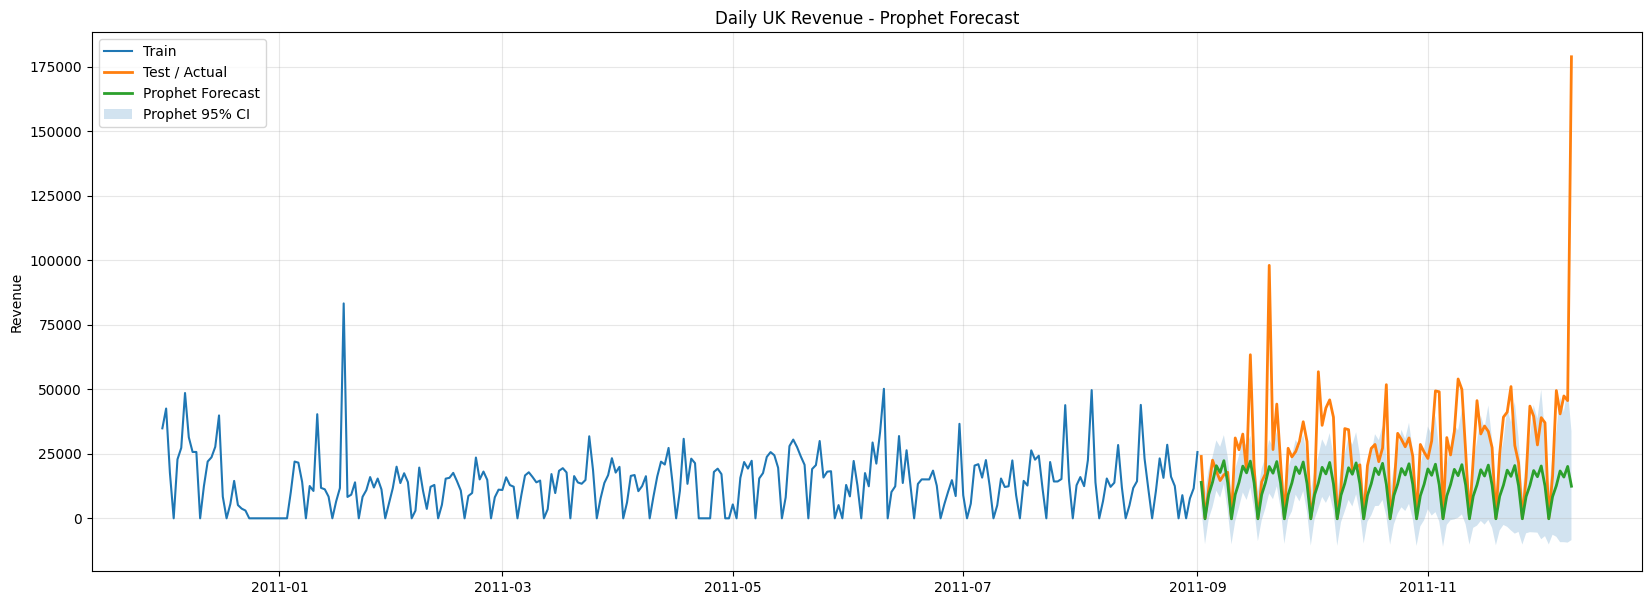

In [150]:
# Plot with confidence intervals
plt.figure(figsize=(20, 7))
plt.plot(train_df["ds"], train_df["y"], label="Train")
plt.plot(test_df["ds"],  test_df["y"],  label="Test / Actual", linewidth=2)
plt.plot(pred_prophet.index, pred_prophet.values, label="Prophet Forecast", linewidth=2)

# 95% CI from Prophet
ci = forecast.set_index("ds")[["yhat_lower", "yhat_upper"]].loc[test_df["ds"]]
plt.fill_between(
    ci.index,
    ci["yhat_lower"],
    ci["yhat_upper"],
    alpha=0.2,
    label="Prophet 95% CI"
)

plt.title("Daily UK Revenue - Prophet Forecast")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [151]:
# Adding holiday effects in Prophet
# Nov–Dec as "peak_season"
holidays = pd.DataFrame({
    "holiday": "peak_season",
    "ds": pd.date_range("2010-11-01", "2010-12-31", freq="D").tolist() +
          pd.date_range("2011-11-01", "2011-12-09", freq="D").tolist()
})

m_holiday = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.5,
    holidays=holidays,
)

m_holiday.fit(train_df)

future = m_holiday.make_future_dataframe(periods=len(test_df), freq="D")
forecast_h = m_holiday.predict(future)
pred_h = forecast_h.set_index("ds")["yhat"].loc[test_df["ds"]]

rmse_h = np.sqrt(mean_squared_error(test_df["y"], pred_h))
mae_h  = mean_absolute_error(test_df["y"], pred_h)
print(f"Prophet + holidays RMSE: {rmse_h:,.2f}")
print(f"Prophet + holidays MAE : {mae_h:,.2f}")

12:32:27 - cmdstanpy - INFO - Chain [1] start processing
12:32:27 - cmdstanpy - INFO - Chain [1] done processing


Prophet + holidays RMSE: 25,493.18
Prophet + holidays MAE : 15,845.72


### Prophet Model Evaluation (Daily UK Revenue)

To complement the SARIMA approach, I also fitted a **Prophet** model on the daily UK revenue series using:

- Daily data (`ds`, `y`) with **weekly seasonality** enabled
- **Yearly and daily seasonality turned off** (only one year of data, no intra-day pattern) 
- Default changepoint detection to allow Prophet to pick up the **Q4 trend shift**

On the same Sep–Dec 2011 test window, the models perform as follows:

- **Prophet (trend + weekly seasonality)**  
  - **RMSE ≈ 25,255**  
  - **MAE  ≈ 15,593**

- **Prophet + custom holiday/peak-season component**  
  - **RMSE ≈ 25,493**  
  - **MAE  ≈ 15,846**

The plain Prophet model is **very close in accuracy** to the SARIMA(2,0,2)(1,1,0,7) model, slightly worse but in the same ballpark, and it similarly captures the **overall upward trend and weekly pattern** while still underestimating the **single extreme holiday spike**.  

Adding an explicit “holiday/peak-season” component does **not improve** the error metrics and actually makes them slightly worse, which suggests that with only one year of history our simple holiday flag is not informative enough for Prophet to reliably learn the magnitude of the Q4 surge.

Overall, Prophet serves as a strong **alternative forecasting baseline** with performance comparable to SARIMA, reinforcing the conclusion that:
- Short-term weekly patterns and trend are predictable,
- But the largest holiday spike behaves like a **rare event/outlier** that neither univariate model can fully anticipate without richer promotional or marketing features.

## Geographic Analysis

In [163]:
! pip install --upgrade kaleido


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [165]:
import plotly.express as px

# Filter out returns and adjustments (negative quantity/price)
geo_data = time_data[(time_data['Quantity'] > 0) & (time_data['UnitPrice'] > 0)]

# Aggregate by Country
country_sales = geo_data.groupby('Country')[['Revenue', 'Quantity']].sum().reset_index()
country_sales["Revenue_M"] = country_sales["Revenue"] / 1e6
country_sales["Revenue_log"] = np.log1p(country_sales["Revenue"])

fig = px.choropleth(
    country_sales,
    locations="Country",
    locationmode="country names",
    color="Revenue_log",                           # smoother colors via log scale
    hover_name="Country",
    hover_data={
        "Revenue": ":,.0f",                        # show full revenue
        "Revenue_M": ":.2f",                       # show in millions
        "Quantity": ":,.0f",
        "Revenue_log": False,                      # hide raw log column
    },
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Global Revenue Distribution by Country (Log-Scaled)",
)

# Map + layout styling
fig.update_geos(
    projection_type="natural earth",
    showcoastlines=True,
    coastlinecolor="white",
    showland=True,
    landcolor="#f5f5f5",
    showcountries=True,
    countrycolor="#b3b3b3",
)

fig.update_layout(
    template="plotly_white",
    title_font=dict(size=22),
    coloraxis_colorbar=dict(
        title="Revenue (log scale)",
        ticks="outside",
    ),
    margin=dict(l=10, r=10, t=60, b=10),
)
# fig.write_image("geo_country_300dpi.png",
#                 width=1800,   # 6 inches * 300 dpi
#                 height=1200,  # 4 inches * 300 dpi
#                 scale=1)
fig.show()

In [166]:
fig.write_html("geo_country_map.html")